In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('Data/Fraud dataset.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.shape

(6362620, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [6]:
df.describe(include='object')

,type,nameOrig,nameDest
count,6362620,6362620,6362620
unique,5,6353307,2722362
top,CASH_OUT,C1902386530,C1286084959
freq,2237500,3,113


## Univariate Analysis

### Transaction Type

**Key Finding**
- CASH_OUT:    35.166331% transactions
- PAYMENT:     33.814608% transactions
- CASH_IN:     21.992261% transactions
- TRANSFER:    8.375622% transactions
- DEBIT:       0.651178% transactions

**Conclusions**
- The maximum transaction are of CASH_OUT with 35% transaction and there are only few transaction of DEBIT with only 0.65% of transactions

In [7]:
df['type'].value_counts()/len(df['type'])*100

type
CASH_OUT    35.166331
PAYMENT     33.814608
CASH_IN     21.992261
TRANSFER     8.375622
DEBIT        0.651178
Name: count, dtype: float64

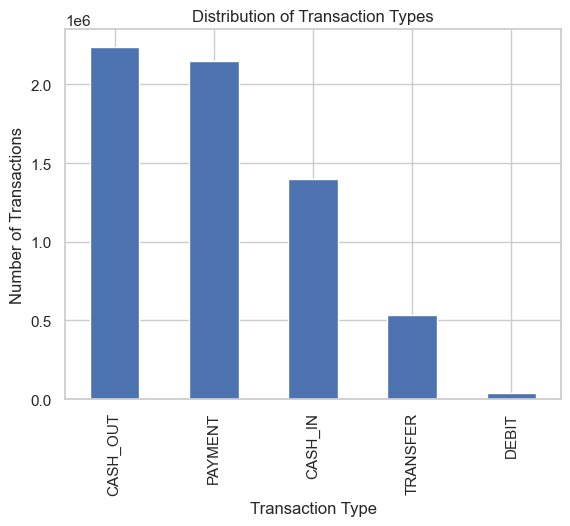

In [8]:
df['type'].value_counts().plot(kind = 'bar')
plt.title('Distribution of Transaction Types')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.show()

In [9]:
fraud_rate = df.groupby('type')['isFraud'].mean() * 100
fraud_rate.sort_values(ascending=False)

type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

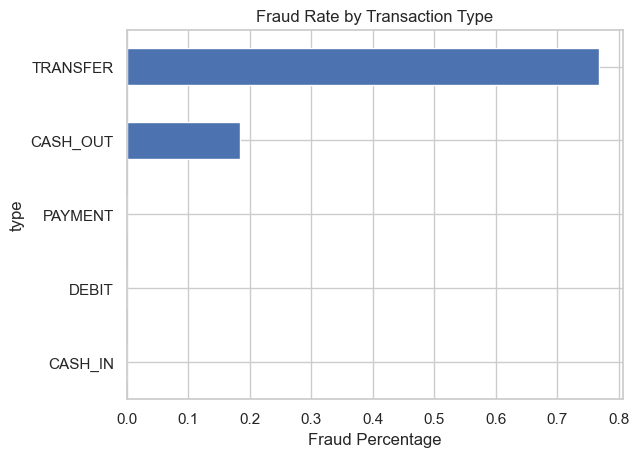

In [10]:
fraud_rate.sort_values().plot(kind='barh')
plt.title('Fraud Rate by Transaction Type')
plt.xlabel('Fraud Percentage')
plt.show()

### Transaction Amount

**Key Finding**
- Transaction Amount is extremely positively skewed (Skewness ≈ 30.99).
- Most of amounts are of relatively low amounts.
- Mean is significantly higher than the median.
- The IQR method identified 5.31% high-value transaction outliers.
- 
**Conclusions**
-Using the IQR method, 338,078 transactions (approximately 5.31% of the dataset) were identified as statistical outliers.

In [11]:
df['amount'].describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

In [12]:
df['amount'].median()

74871.94

In [13]:
df['amount'].mean()

np.float64(179861.90354913071)

<Axes: ylabel='Frequency'>

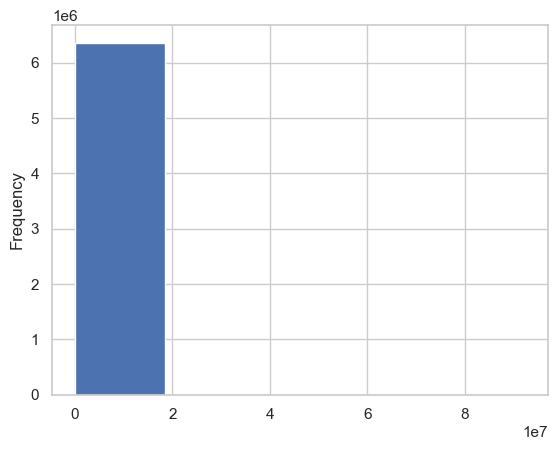

In [14]:
df['amount'].plot(kind='hist', bins = 5)

<Axes: xlabel='amount'>

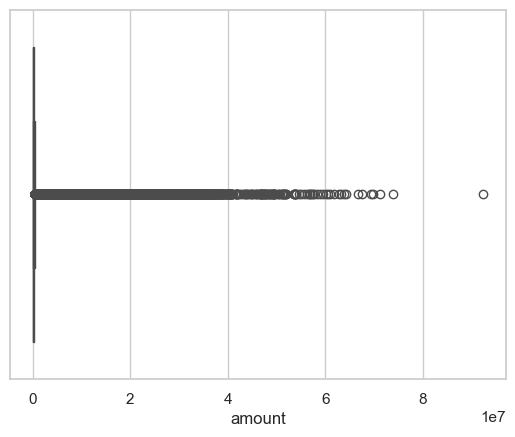

In [15]:
sns.boxplot(x=df['amount'])

<Axes: ylabel='Density'>

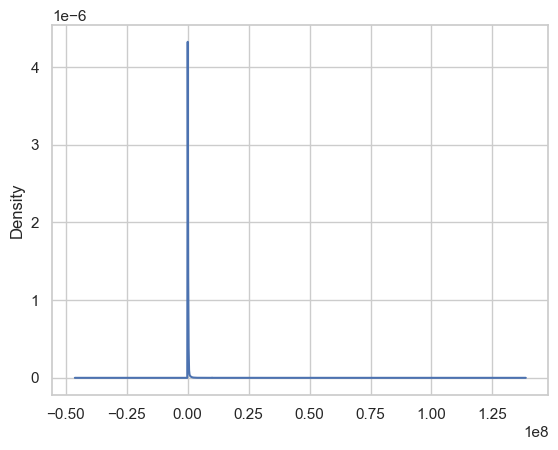

In [16]:
df['amount'].plot(kind='kde')

In [17]:
df['amount'].skew()

np.float64(30.99394948249041)

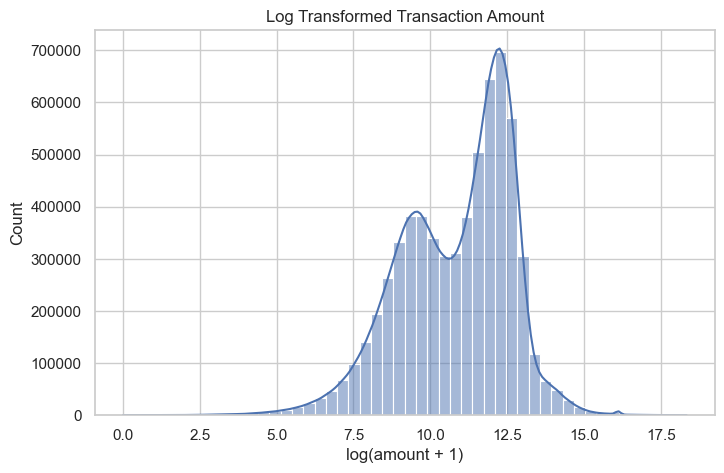

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df['amount']), bins=50, kde=True)
plt.title("Log Transformed Transaction Amount")
plt.xlabel("log(amount + 1)")
plt.show()

In [19]:
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

(df['amount'] > upper).sum()

np.int64(338078)

In [20]:
((df['amount'] > upper).sum() / len(df))*100

np.float64(5.313502928039078)

### oldbalanceOrg

**Key Finding**
- The `oldbalanceOrg` feature is highly right-skewed, with a skewness of approximately 5.25.
- The median balance (14,208) is much lower than the mean balance (83,388.31), indicating that the distribution is strongly affected by high-value observations.
- A large proportion of transactions have an original account balance close to zero.
- The distribution has a long right tail, with values reaching up to approximately 59.58 million.
- The boxplot shows numerous extreme high-value observations.
**Conclusions**
The `oldbalanceOrg` feature has a highly positively skewed distribution with a large concentration of observations near zero and a long right tail. The extreme values represent accounts with substantially higher balances and should not be removed blindly, as they may contain useful information for fraud detection.


In [21]:
df['oldbalanceOrg'].describe()

count    6.362620e+06
mean     8.338831e+05
std      2.888243e+06
min      0.000000e+00
25%      0.000000e+00
50%      1.420800e+04
75%      1.073152e+05
max      5.958504e+07
Name: oldbalanceOrg, dtype: float64

In [22]:
df['oldbalanceOrg'].skew()

np.float64(5.249136420603118)

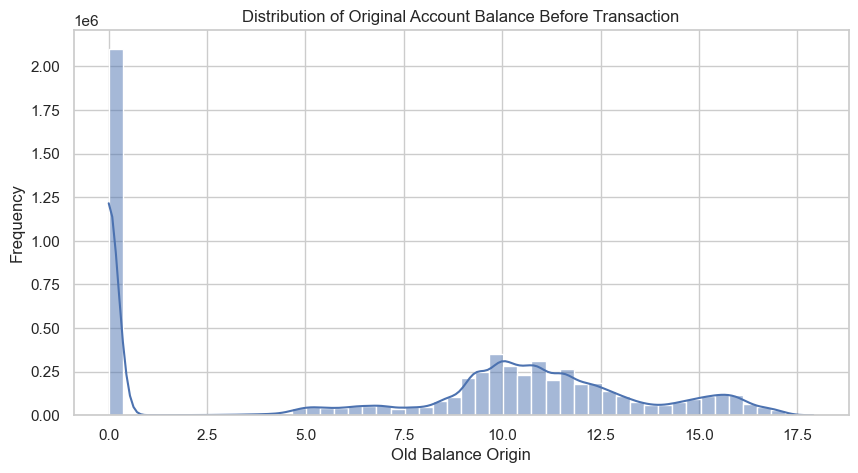

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(np.log1p(df['oldbalanceOrg']), bins=50, kde=True)

plt.title('Distribution of Original Account Balance Before Transaction')
plt.xlabel('Old Balance Origin')
plt.ylabel('Frequency')

plt.show()

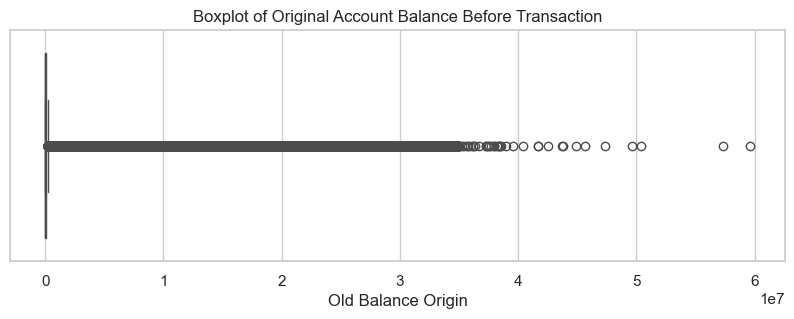

In [24]:
plt.figure(figsize=(10,3))

sns.boxplot(x=df['oldbalanceOrg'])

plt.title('Boxplot of Original Account Balance Before Transaction')
plt.xlabel('Old Balance Origin')

plt.show()

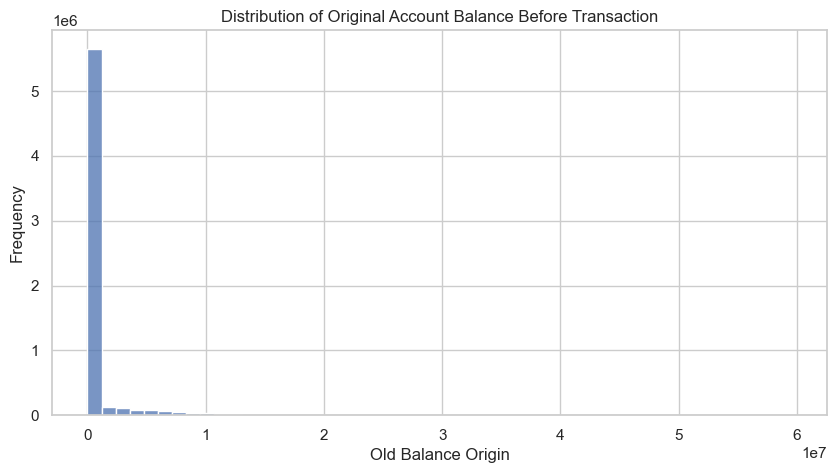

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(df['oldbalanceOrg'], bins=50)

plt.title('Distribution of Original Account Balance Before Transaction')
plt.xlabel('Old Balance Origin')
plt.ylabel('Frequency')

plt.show()

In [28]:
df['oldbalanceOrg'].median()

14208.0

In [29]:
df['oldbalanceOrg'].mean()

np.float64(833883.1040744866)

### newbalanceOrig

**Key Finding**
- The `newbalanceOrig` feature is highly positively skewed, with a skewness of approximately 5.18.
- The median and first quartile are both 0, indicating that a large proportion of transactions have zero balance after the transaction.
- The mean balance (855,113.67) is considerably higher than the median because of the presence of high-value observations.
- The distribution has a very long right tail, with the maximum balance reaching approximately 49.58 million.
- The boxplot shows numerous extreme high-value observations.


**Conclusions**

The `newbalanceOrig` distribution is highly right-skewed and heavily concentrated around zero. The large difference between the mean and median indicates that the distribution is strongly influenced by high-value balances. These extreme observations should not be removed blindly because account balance information may be useful for fraud detection.

In [31]:
df['newbalanceOrig'].describe()

count    6.362620e+06
mean     8.551137e+05
std      2.924049e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.442584e+05
max      4.958504e+07
Name: newbalanceOrig, dtype: float64

In [32]:
df['newbalanceOrig'].mean()

np.float64(855113.6685785886)

In [33]:
df['newbalanceOrig'].median()

0.0

In [34]:
df['newbalanceOrig'].skew()

np.float64(5.176884001159237)

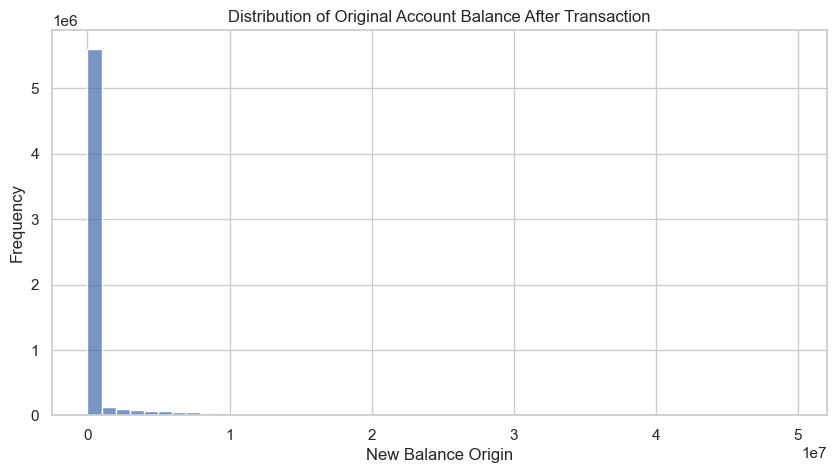

In [35]:
plt.figure(figsize=(10,5))

sns.histplot(df['newbalanceOrig'], bins=50)

plt.title('Distribution of Original Account Balance After Transaction')
plt.xlabel('New Balance Origin')
plt.ylabel('Frequency')

plt.show()

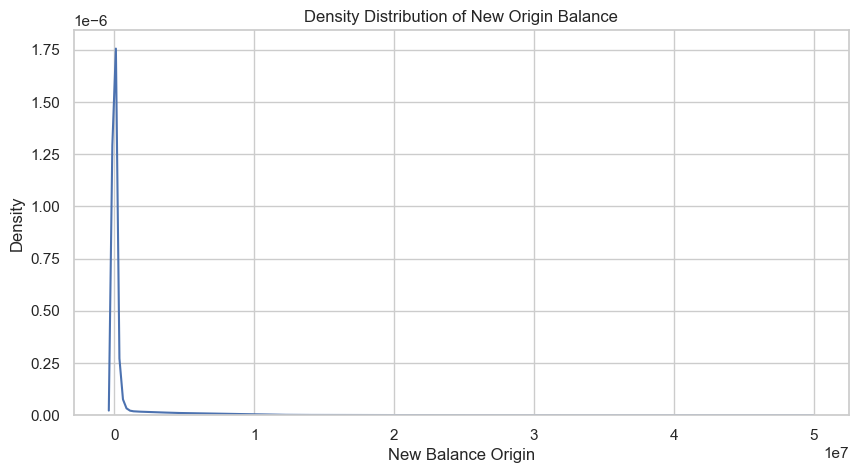

In [36]:
plt.figure(figsize=(10,5))

sns.kdeplot(df['newbalanceOrig'])

plt.title('Density Distribution of New Origin Balance')
plt.xlabel('New Balance Origin')

plt.show()

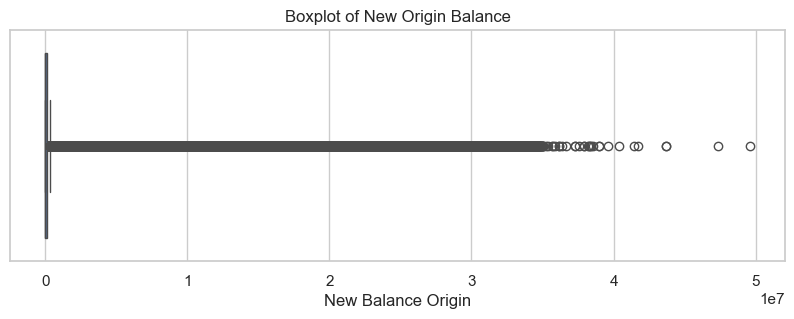

In [39]:
plt.figure(figsize=(10,3))

sns.boxplot(x=df['newbalanceOrig'])

plt.title('Boxplot of New Origin Balance')
plt.xlabel('New Balance Origin')

plt.show()

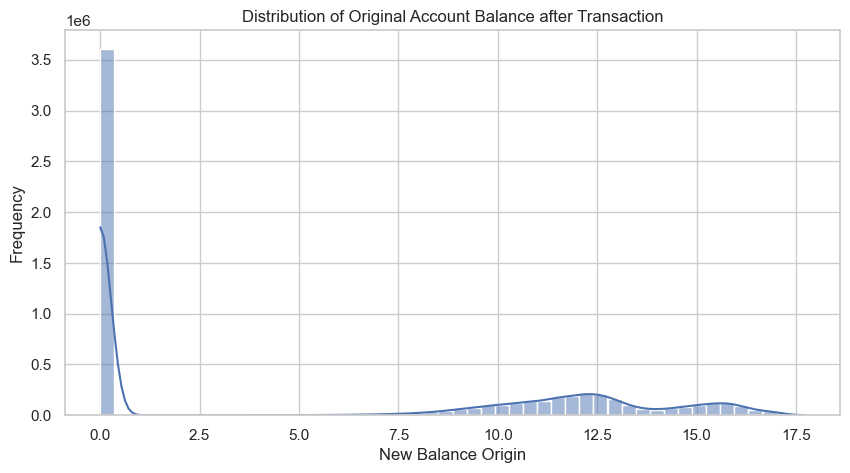

In [38]:
plt.figure(figsize=(10,5))

sns.histplot(np.log1p(df['newbalanceOrig']), bins=50, kde=True)

plt.title('Distribution of Original Account Balance after Transaction')
plt.xlabel('New Balance Origin')
plt.ylabel('Frequency')

plt.show()

### 4.5 oldbalanceDest

**Key Finding**
- The `oldbalanceDest` feature is extremely right-skewed, with a skewness of approximately 19.92.
- The median balance (132,705.66) is considerably lower than the mean balance (1,100,701.67), indicating the strong influence of high-value observations.
- At least 25% of transactions have a destination balance of 0.
- The distribution has a very long right tail, with the maximum balance reaching approximately 356.02 million.
- The boxplot shows numerous extreme high-value observations.

**Conclusions**
The `oldbalanceDest` feature has an extremely positively skewed distribution, with most observations concentrated around relatively low balances and a small number of very large balances. The extreme values should not be removed blindly because they may contain useful information for identifying fraudulent transactions.

In [40]:
df['oldbalanceDest'].describe()

count    6.362620e+06
mean     1.100702e+06
std      3.399180e+06
min      0.000000e+00
25%      0.000000e+00
50%      1.327057e+05
75%      9.430367e+05
max      3.560159e+08
Name: oldbalanceDest, dtype: float64

In [41]:
df['oldbalanceDest'].skew()

np.float64(19.92175791579108)

In [42]:
df['oldbalanceDest'].mean()

np.float64(1100701.666519649)

In [43]:
df['oldbalanceDest'].median()

132705.66499999998

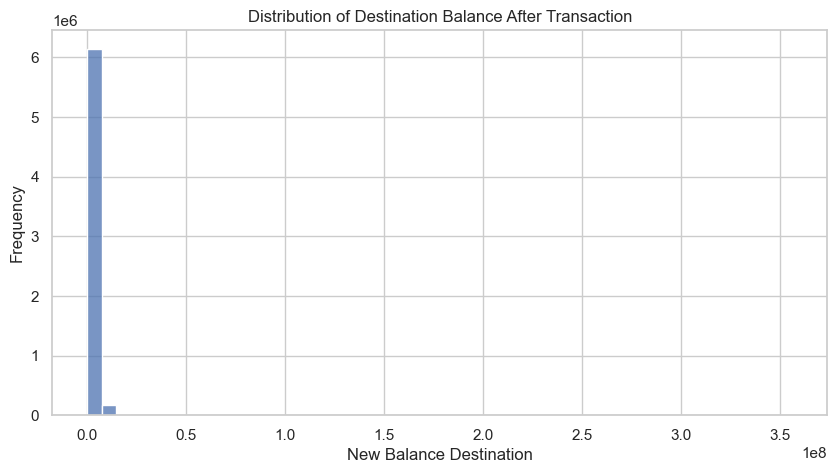

In [48]:
plt.figure(figsize=(10,5))

sns.histplot(df['newbalanceDest'], bins=50)

plt.title('Distribution of Destination Balance After Transaction')
plt.xlabel('New Balance Destination')
plt.ylabel('Frequency')

plt.show()

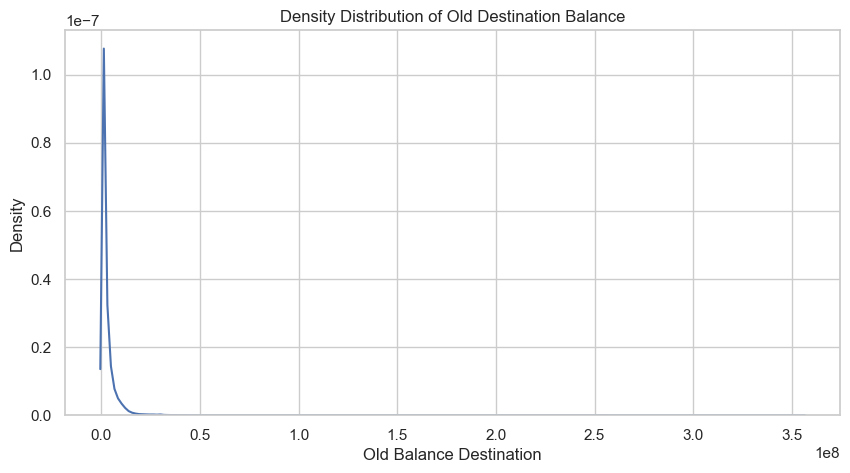

In [45]:
plt.figure(figsize=(10,5))

sns.kdeplot(df['oldbalanceDest'])

plt.title('Density Distribution of Old Destination Balance')
plt.xlabel('Old Balance Destination')

plt.show()

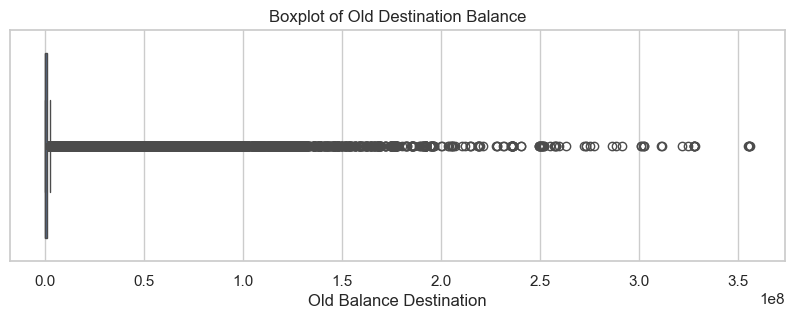

In [54]:
plt.figure(figsize=(10,3))

sns.boxplot(x=df['oldbalanceDest'])

plt.title('Boxplot of Old Destination Balance')
plt.xlabel('Old Balance Destination')

plt.show()

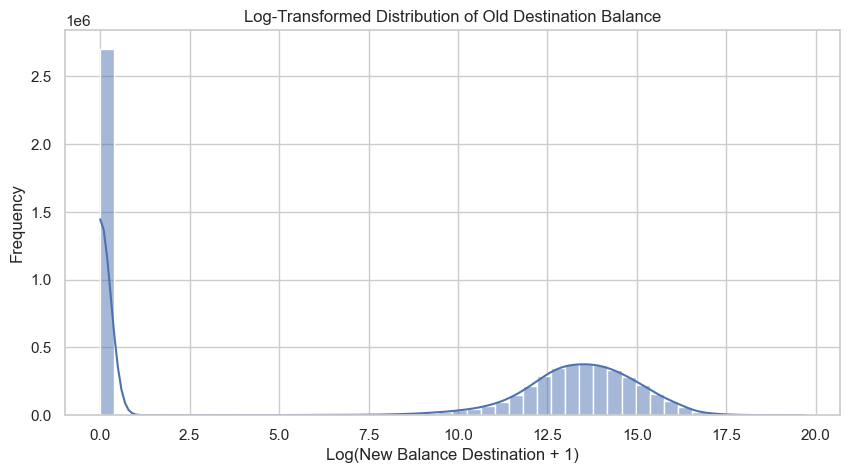

In [83]:
plt.figure(figsize=(10,5))

sns.histplot(np.log1p(df['oldbalanceDest']), bins=50, kde=True)

plt.title('Log-Transformed Distribution of Old Destination Balance')
plt.xlabel('Log(New Balance Destination + 1)')
plt.ylabel('Frequency')

plt.show()

### 4.6 New Destination Balance — newbalanceDest

**Key Finding**
- The `newbalanceDest` feature is highly right-skewed, with a skewness of approximately 19.35.
- The median destination balance (214,661.44) is substantially lower than the mean (1,224,996.40), indicating the influence of very large balance values.
- At least 25% of transactions have a destination balance of 0.
- The distribution contains extremely large values, with a maximum balance of approximately 356.18 million.
- The histogram and KDE show that most observations are concentrated near lower balance values, while a long right tail extends toward very high balances.
- The boxplot confirms the presence of numerous extreme values.

**Conclusions**
The `newbalanceDest` feature has an extremely positively skewed distribution. Most destination balances are relatively small or zero, while a small number of transactions have exceptionally large balances. The extreme values should be retained during EDA because they may contain useful information for identifying unusual or fraudulent transactions.

In [56]:
df['newbalanceDest'].describe()

count    6.362620e+06
mean     1.224996e+06
std      3.674129e+06
min      0.000000e+00
25%      0.000000e+00
50%      2.146614e+05
75%      1.111909e+06
max      3.561793e+08
Name: newbalanceDest, dtype: float64

In [57]:
df['newbalanceDest'].mean()

np.float64(1224996.3982019294)

In [58]:
df['newbalanceDest'].median()

214661.44

In [59]:
df['newbalanceDest'].skew()

np.float64(19.352302057660125)

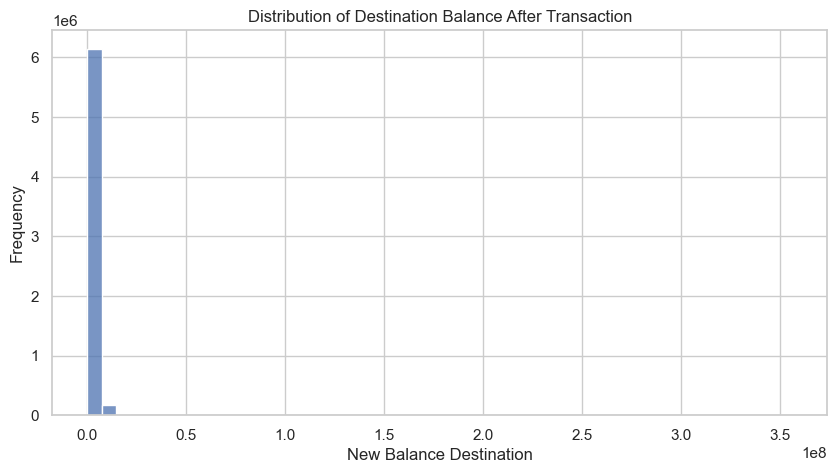

In [60]:
plt.figure(figsize=(10,5))

sns.histplot(df['newbalanceDest'], bins=50)

plt.title('Distribution of Destination Balance After Transaction')
plt.xlabel('New Balance Destination')
plt.ylabel('Frequency')

plt.show()

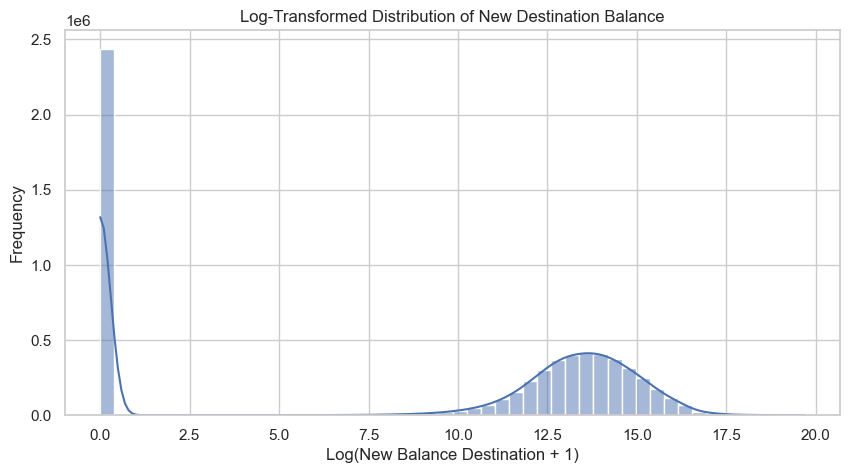

In [84]:
plt.figure(figsize=(10,5))

sns.histplot(np.log1p(df['newbalanceDest']), bins=50, kde=True)

plt.title('Log-Transformed Distribution of New Destination Balance')
plt.xlabel('Log(New Balance Destination + 1)')
plt.ylabel('Frequency')

plt.show()

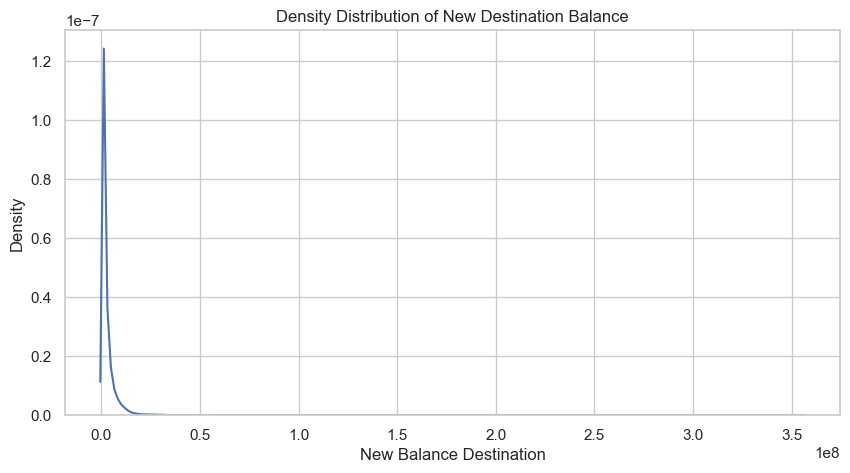

In [61]:
plt.figure(figsize=(10,5))

sns.kdeplot(df['newbalanceDest'])

plt.title('Density Distribution of New Destination Balance')
plt.xlabel('New Balance Destination')

plt.show()

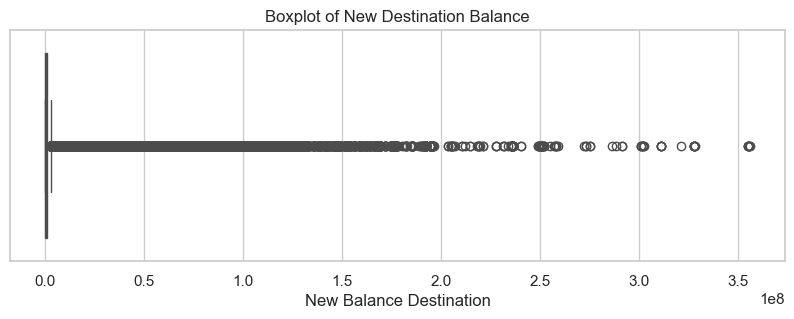

In [62]:
plt.figure(figsize=(10,3))

sns.boxplot(x=df['newbalanceDest'])

plt.title('Boxplot of New Destination Balance')
plt.xlabel('New Balance Destination')

plt.show()

### 4.7 step
-step represents time, with each step corresponding to one hour in the simulation.

**Key Finding**
- The dataset contains **743 unique time steps**, ranging from step 1 to step 743.
- The mean step is approximately **243.40**, while the median is **239**, indicating that the center of the distribution is around the early-to-middle portion of the simulation.
- The middle 50% of transactions occur between steps **156 and 335**.
- The histogram shows that transaction activity is concentrated mainly between approximately steps **1 and 400**.
- Transaction frequency decreases considerably after step 400, although transactions continue to occur up to step 743.
- The skewness is approximately **0.375**, indicating a **slightly right-skewed** distribution rather than a strongly skewed one.
- The boxplot shows several higher-step observations extending toward the upper end of the time range.

**Conclusions**
The `step` variable shows that transaction activity is not evenly distributed over time. Most transactions occur during the earlier and middle portions of the simulation, while transaction frequency decreases in the later steps. Since `step` represents time, this temporal variation may be useful when investigating changes in transaction behavior and fraud patterns over time.

In [64]:
df['step'].describe()

count    6.362620e+06
mean     2.433972e+02
std      1.423320e+02
min      1.000000e+00
25%      1.560000e+02
50%      2.390000e+02
75%      3.350000e+02
max      7.430000e+02
Name: step, dtype: float64

In [65]:
df['step'].nunique()

743

In [66]:
df['step'].value_counts().sort_index()

step
1      2708
2      1014
3       552
4       565
5       665
       ... 
739      10
740       6
741      22
742      14
743       8
Name: count, Length: 743, dtype: int64

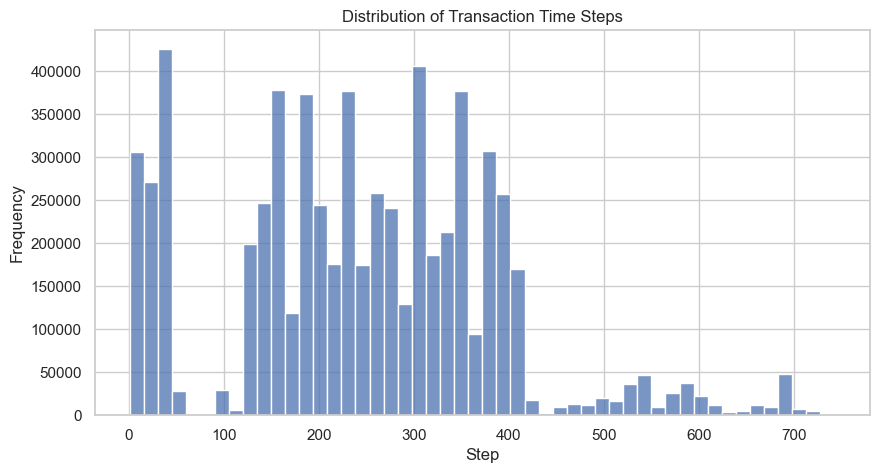

In [67]:
plt.figure(figsize=(10,5))

sns.histplot(df['step'], bins=50)

plt.title('Distribution of Transaction Time Steps')
plt.xlabel('Step')
plt.ylabel('Frequency')

plt.show()

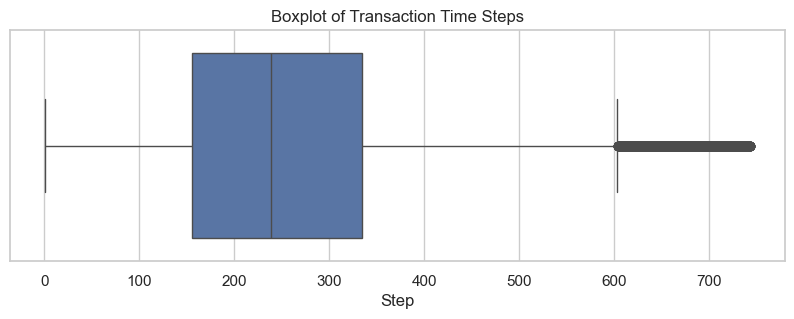

In [68]:
plt.figure(figsize=(10,3))

sns.boxplot(x=df['step'])

plt.title('Boxplot of Transaction Time Steps')
plt.xlabel('Step')

plt.show()

In [69]:
df['step'].skew()

np.float64(0.37517688846984876)

### 4.8 nameOrig and nameDest

**Key Finding**
- `nameOrig` contains **6,353,307 unique accounts**, indicating that most origin accounts appear very few times in the dataset.
- `nameDest` contains **2,722,362 unique accounts**, which is considerably fewer than the number of unique origin accounts.
- The most frequent `nameOrig` values occur only **3 times**, suggesting relatively low repetition among source accounts.
- In contrast, the most frequent `nameDest` values occur around **97–113 times**, indicating that destination accounts are reused across many transactions.
- Therefore, `nameDest` has considerably higher transaction-level repetition than `nameOrig`.

**Conclusions**
The `nameOrig` and `nameDest` variables represent account identifiers rather than continuous numerical variables. Their high cardinality makes direct statistical analysis or visualization less meaningful. However, their frequency patterns provide useful information: destination accounts are reused much more frequently than origin accounts, while most origin accounts appear only a small number of times.

These variables may be useful for further fraud analysis by examining transaction frequency and account-level behavior, rather than treating the identifiers as numerical features.

In [70]:
df['nameOrig'].nunique()

6353307

In [71]:
df['nameDest'].nunique()

2722362

In [72]:
df['nameOrig'].value_counts().head(10)

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

In [73]:
df['nameDest'].value_counts().head(10)

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

### 4.9 isFraud

**Key Finding**
- The dataset contains 6,354,407 legitimate transactions and 8,213 fraudulent transactions.
- Fraudulent transactions represent only 0.129082% of the total transactions, while 99.870918% are legitimate.
- This shows that the target variable `isFraud` is extremely imbalanced.
- The number of legitimate transactions is much higher than the number of fraudulent transactions.

**Conclusions**

The `isFraud` variable is highly imbalanced, with fraudulent transactions accounting for only 0.129082% of all transactions. This severe class imbalance is an important challenge for the fraud detection model because a model could achieve high accuracy by predominantly predicting legitimate transactions. Therefore, appropriate evaluation metrics and imbalance-handling techniques will be required during the modeling stage.

In [74]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [75]:
df['isFraud'].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

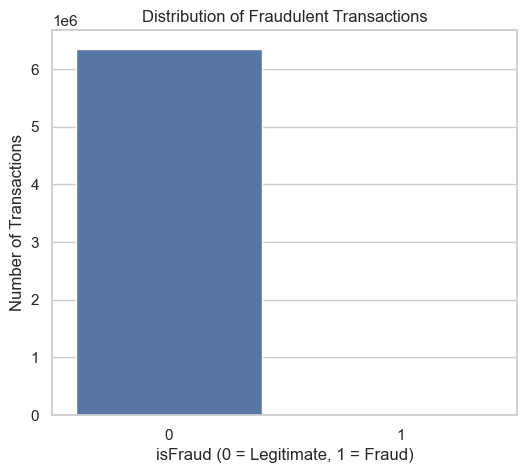

In [81]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='isFraud')

plt.title('Distribution of Fraudulent Transactions')
plt.xlabel('isFraud (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Number of Transactions')

plt.show()

### 4.10 isFlaggedFraud

**Key Finding**
- The `isFlaggedFraud` feature contains 6,362,604 transactions that were not flagged by the bank's fraud detection system.
- Only 16 transactions were flagged as fraudulent.
- Approximately 99.999749% of transactions were not flagged, while only 0.000251% were flagged.
- The feature is therefore extremely imbalanced.

**Conclusions**

The `isFlaggedFraud` feature has very limited variation because only 16 transactions were flagged by the bank's rule-based fraud detection system. This indicates that the bank's existing rule-based system flagged very few transactions compared with the total number of transactions. Since `isFraud` is the actual fraud target, `isFlaggedFraud` should not be treated as the prediction target.

In [78]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [79]:
df['isFlaggedFraud'].value_counts(normalize=True) * 100

isFlaggedFraud
0    99.999749
1     0.000251
Name: proportion, dtype: float64

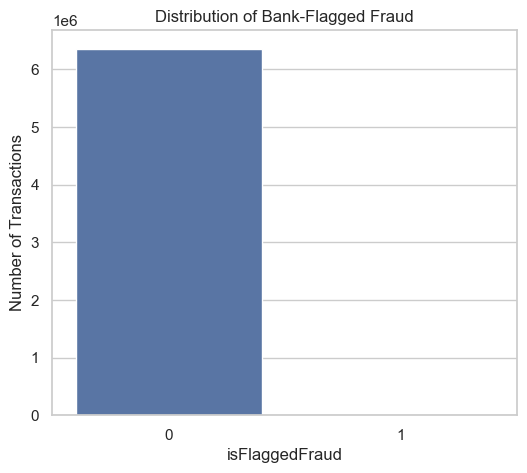

In [80]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='isFlaggedFraud')

plt.title('Distribution of Bank-Flagged Fraud')
plt.xlabel('isFlaggedFraud')
plt.ylabel('Number of Transactions')

plt.show()

## Bivariate Analysis

## 5.1 Transaction Type vs Fraud

### Key Findings

- Fraudulent transactions are observed only in CASH_OUT and TRANSFER transactions.
- CASH_IN, DEBIT, and PAYMENT transactions contain no fraudulent transactions in the dataset.
- TRANSFER has the highest fraud rate at approximately 0.769%, while CASH_OUT has a fraud rate of approximately 0.184%.
- Although CASH_OUT has slightly more fraudulent transactions in absolute numbers, TRANSFER has a substantially higher proportion of fraudulent transactions.

### Conclusion

Transaction type shows a strong relationship with fraud in this dataset. Fraud is concentrated in TRANSFER and CASH_OUT transactions, with TRANSFER showing the highest fraud rate. Therefore, transaction type appears to be an important variable for identifying potentially fraudulent transactions.

In [86]:
pd.crosstab(df['type'], df['isFraud'])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [88]:
fraud_rate = pd.crosstab(
    df['type'],
    df['isFraud'],
    normalize='index'
) * 100

fraud_rate

isFraud,0,1
type,,
CASH_IN,100.000000,0.000000
CASH_OUT,99.816045,0.183955
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,99.231201,0.768799


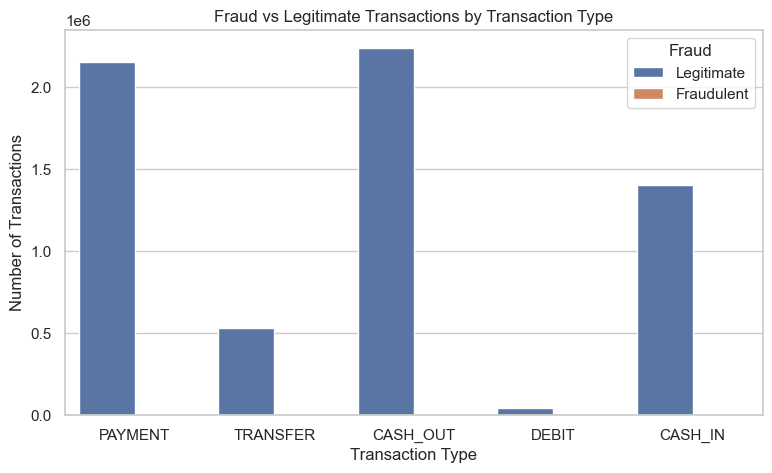

In [89]:
plt.figure(figsize=(9,5))

sns.countplot(data=df, x='type', hue='isFraud')

plt.title('Fraud vs Legitimate Transactions by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.legend(title='Fraud', labels=['Legitimate', 'Fraudulent'])

plt.show()

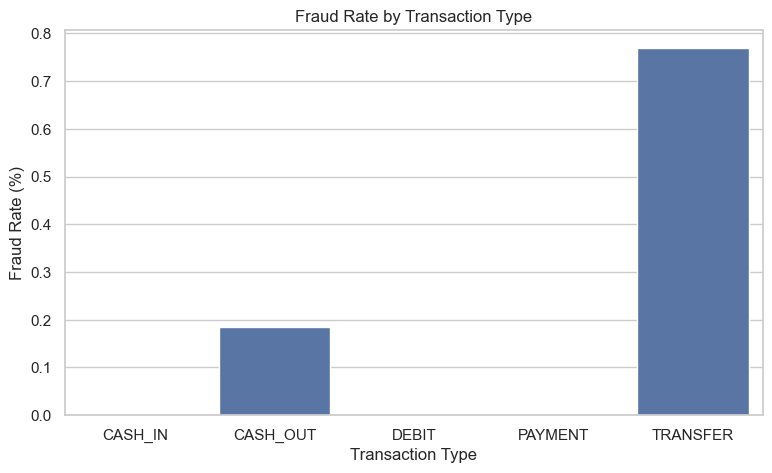

In [90]:
fraud_rate_by_type = df.groupby('type')['isFraud'].mean() * 100

plt.figure(figsize=(9,5))

sns.barplot(
    x=fraud_rate_by_type.index,
    y=fraud_rate_by_type.values
)

plt.title('Fraud Rate by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')

plt.show()

In [91]:
fraud_rate_by_type.sort_values(ascending=False)

type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

## 5.2 Transaction Amount vs Fraud

### Key Findings

- Fraudulent transactions have substantially higher transaction amounts compared with legitimate transactions.
- The median transaction amount for fraudulent transactions is approximately ₹441,423, compared with approximately ₹74,685 for legitimate transactions.
- The mean transaction amount for fraudulent transactions is approximately ₹1.47 million, while for legitimate transactions it is approximately ₹178,197.
- The 75th percentile of fraudulent transaction amounts is approximately ₹1.52 million, much higher than the ₹208,365 observed for legitimate transactions.
- Both distributions are highly right-skewed, with extreme transaction amounts present in the dataset.

### Conclusion

Transaction amount shows a strong association with fraud. Fraudulent transactions tend to involve substantially larger amounts than legitimate transactions. Therefore, transaction amount may be an important feature for fraud detection.


In [92]:
df.groupby('isFraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [93]:
df.groupby('isFraud')['amount'].median()

isFraud
0     74684.72
1    441423.44
Name: amount, dtype: float64

In [95]:
df.groupby('isFraud')['amount'].mean()

isFraud
0    1.781970e+05
1    1.467967e+06
Name: amount, dtype: float64

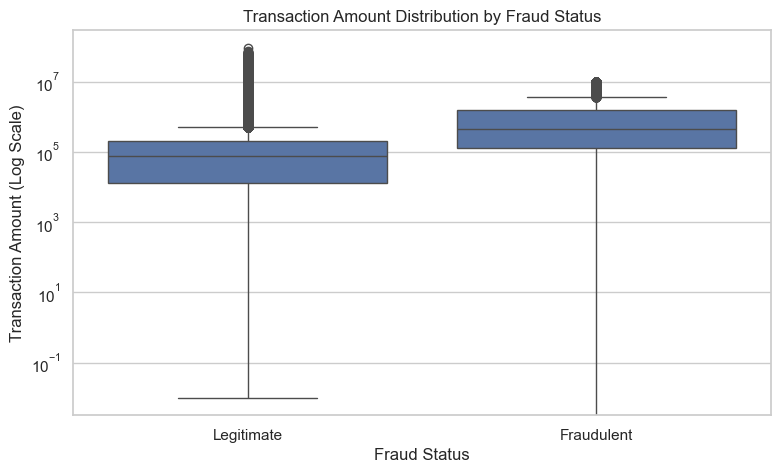

In [96]:
plt.figure(figsize=(9,5))

sns.boxplot(data=df, x='isFraud', y='amount')

plt.yscale('log')

plt.title('Transaction Amount Distribution by Fraud Status')
plt.xlabel('Fraud Status')
plt.ylabel('Transaction Amount (Log Scale)')
plt.xticks([0, 1], ['Legitimate', 'Fraudulent'])

plt.show()

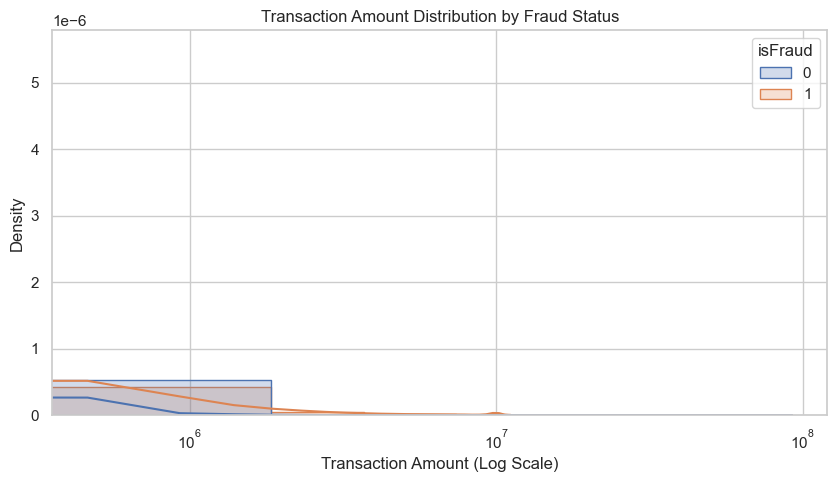

In [97]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='amount',
    hue='isFraud',
    bins=50,
    kde=True,
    element='step',
    stat='density',
    common_norm=False
)

plt.xscale('log')

plt.title('Transaction Amount Distribution by Fraud Status')
plt.xlabel('Transaction Amount (Log Scale)')
plt.ylabel('Density')

plt.show()

## 5.3 Transaction Time Step vs Fraud

### Key Finding

After filtering out time steps with fewer than 100 transactions, the fraud rate still varies considerably across the simulation period. The 24-step rolling fraud rate shows a relatively low fraud rate during the earlier part of the simulation, generally below 0.6%.

However, after approximately step 400, the rolling fraud rate increases and remains at a higher level, generally around 0.8%–1.3%. This indicates that fraudulent activity became relatively more frequent during the later stages of the simulation.

### Conclusion

Transaction time appears to have some relationship with fraud occurrence in this dataset. Fraud activity is relatively higher during the later time steps compared with the earlier period. However, time alone cannot explain fraud and should be considered together with transaction type, transaction amount, and balance-related features.

In [98]:
fraud_by_step = df.groupby('step')['isFraud'].agg(['count', 'sum', 'mean'])
fraud_by_step['fraud_rate'] = fraud_by_step['mean'] * 100
fraud_by_step.head()

,count,sum,mean,fraud_rate
step,,,,
1,2708,16,0.005908,0.590842
2,1014,8,0.007890,0.788955
3,552,4,0.007246,0.724638
4,565,10,0.017699,1.769912
5,665,6,0.009023,0.902256


In [102]:
fraud_by_step_filtered = fraud_by_step[fraud_by_step['count'] >= 100]
fraud_by_step_filtered.shape

(402, 4)

In [103]:
fraud_by_step_filtered.sort_values(
    'fraud_rate',
    ascending=False
).head(10)

,count,sum,mean,fraud_rate
step,,,,
578,269,20,0.074349,7.434944
195,141,10,0.070922,7.092199
436,248,16,0.064516,6.451613
716,140,8,0.057143,5.714286
531,250,14,0.056000,5.600000
672,153,8,0.052288,5.228758
509,288,14,0.048611,4.861111
413,289,14,0.048443,4.844291
555,144,6,0.041667,4.166667


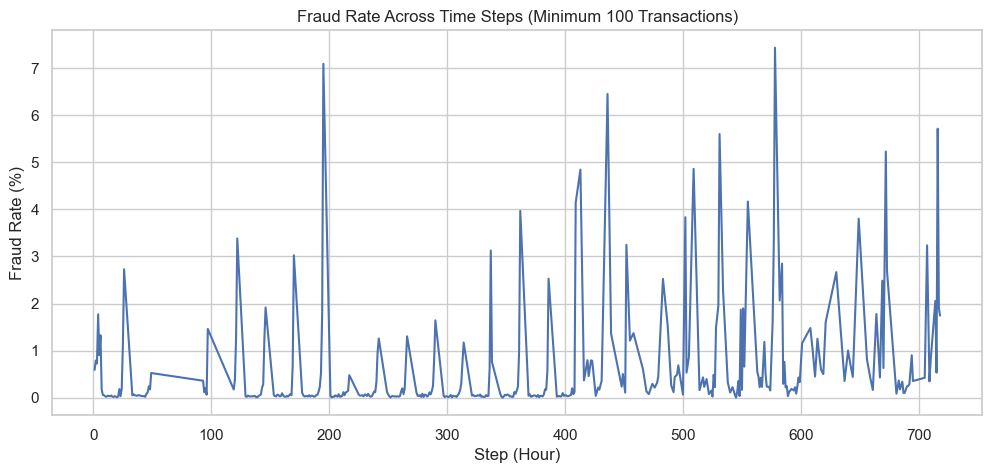

In [104]:
plt.figure(figsize=(12,5))

plt.plot(
    fraud_by_step_filtered.index,
    fraud_by_step_filtered['fraud_rate']
)

plt.title('Fraud Rate Across Time Steps (Minimum 100 Transactions)')
plt.xlabel('Step (Hour)')
plt.ylabel('Fraud Rate (%)')

plt.show()

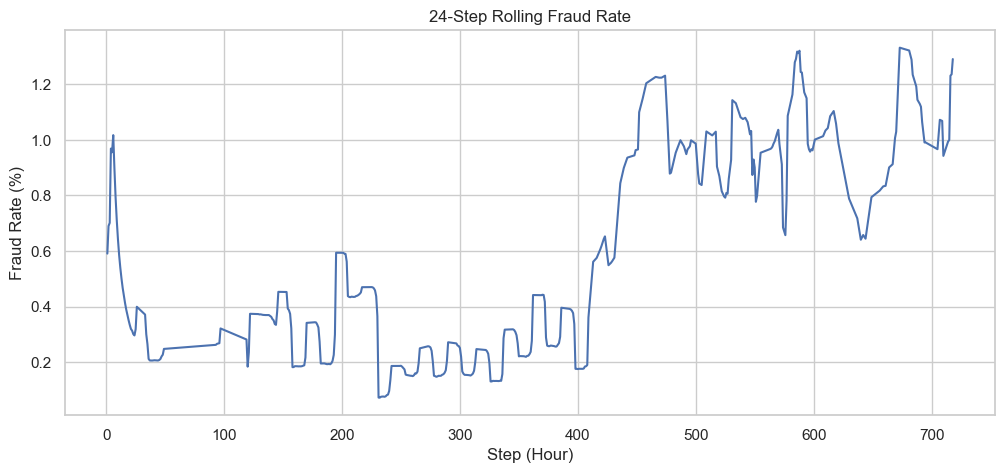

In [107]:
fraud_by_step_filtered = fraud_by_step_filtered.sort_index()

fraud_by_step_filtered['rolling_fraud_rate'] = (
    fraud_by_step_filtered['fraud_rate']
    .rolling(window=24, min_periods=1)
    .mean()
)

plt.figure(figsize=(12,5))

plt.plot(
    fraud_by_step_filtered.index,
    fraud_by_step_filtered['rolling_fraud_rate']
)

plt.title('24-Step Rolling Fraud Rate')
plt.xlabel('Step (Hour)')
plt.ylabel('Fraud Rate (%)')

plt.show()

## 5.4 Account Balance Changes vs Fraud

### 5.4.1 Origin Account Balance vs Fraud
Fraudulent transactions tend to originate from accounts with higher balances compared with legitimate transactions. The median origin balance before a transaction is approximately ₹438,983 for fraudulent transactions, compared with ₹140,690 for legitimate transactions.

The boxplot also shows that the distribution of `oldbalanceOrg` is shifted toward higher values for fraudulent transactions. This suggests that the sender's account balance before a transaction may contain useful information for identifying fraudulent activity.

### Conclusion

The origin account balance before a transaction shows a noticeable association with fraud. However, balance alone is not sufficient to determine whether a transaction is fraudulent and should be analyzed together with transaction amount and the resulting balance.

In [108]:
df.groupby('isFraud')[['oldbalanceOrg', 'newbalanceOrig']].mean()

,oldbalanceOrg,newbalanceOrig
isFraud,,
0,8.328287e+05,855970.228109
1,1.649668e+06,192392.631836


In [109]:
df.groupby('isFraud')[['oldbalanceOrg', 'newbalanceOrig']].median()

,oldbalanceOrg,newbalanceOrig
isFraud,,
0,14069.00,0.0
1,438983.45,0.0


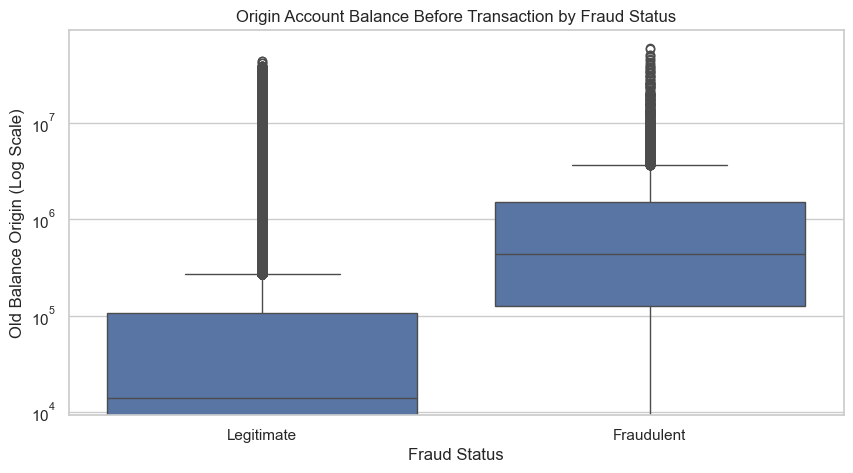

In [112]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='isFraud',
    y='oldbalanceOrg'
)

plt.yscale('log')

plt.title('Origin Account Balance Before Transaction by Fraud Status')
plt.xlabel('Fraud Status')
plt.ylabel('Old Balance Origin (Log Scale)')
plt.xticks([0, 1], ['Legitimate', 'Fraudulent'])

plt.show()

### 5.4.2 New Origin Account Balance vs Fraud

### Key Finding

After the transaction, fraudulent transactions tend to leave the origin account with a much lower remaining balance compared with legitimate transactions. The mean `newbalanceOrig` is approximately ₹192,393 for fraudulent transactions, compared with ₹855,970 for legitimate transactions.

The median is ₹0 for both groups, indicating that zero remaining balance is common in both legitimate and fraudulent transactions. Therefore, the mean and overall distribution provide more useful information for comparison.

### Conclusion

The remaining balance of the origin account shows a noticeable relationship with fraud. Fraudulent transactions are more strongly associated with accounts having very low or zero balances after the transaction. This feature may therefore be useful for fraud detection when combined with transaction amount and the account's balance before the transaction.

In [114]:
df.groupby('isFraud')[['newbalanceOrig']].mean()

,newbalanceOrig
isFraud,
0,855970.228109
1,192392.631836


In [115]:
df.groupby('isFraud')[['newbalanceOrig']].median()

,newbalanceOrig
isFraud,
0,0.0
1,0.0


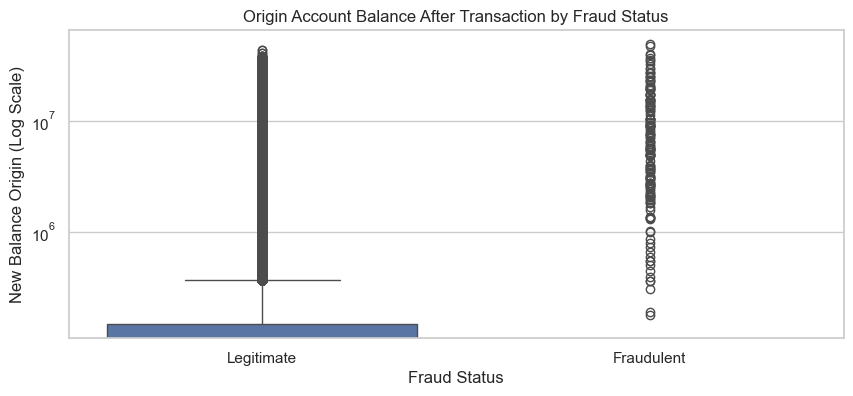

In [116]:
plt.figure(figsize=(10,4))

sns.boxplot(
    data=df,
    x='isFraud',
    y='newbalanceOrig'
)

plt.yscale('log')

plt.title('Origin Account Balance After Transaction by Fraud Status')
plt.xlabel('Fraud Status')
plt.ylabel('New Balance Origin (Log Scale)')
plt.xticks([0, 1], ['Legitimate', 'Fraudulent'])

plt.show()

### 5.4.3 Origin Account Balance Change vs Fraud
### Key Finding

The change in the origin account balance shows a strong relationship with fraud. The median balance change for fraudulent transactions is approximately ₹436,317, compared with ₹0 for legitimate transactions.

Fraudulent transactions therefore tend to involve a substantial reduction in the origin account balance.

### Conclusion

`balance_change_orig` appears to be an important feature for identifying fraudulent transactions. Large reductions in the origin account balance are considerably more common among fraudulent transactions.

Some legitimate transactions show negative balance changes, indicating that the recorded account balances do not always reconcile perfectly with the transaction amount. This should be considered when interpreting the feature.

In [118]:
df['balance_change_orig'] = (
    df['oldbalanceOrg'] - df['newbalanceOrig']
)

df.groupby('isFraud')['balance_change_orig'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,-2.314152e+04,1.062233e+05,-1915267.9,0.00,0.00,10102.125,4164236.31
1,8213.0,1.457275e+06,2.396099e+06,0.0,124582.58,436317.49,1503034.860,10000000.00


In [119]:
df.groupby('isFraud')['balance_change_orig'].median()

isFraud
0         0.00
1    436317.49
Name: balance_change_orig, dtype: float64

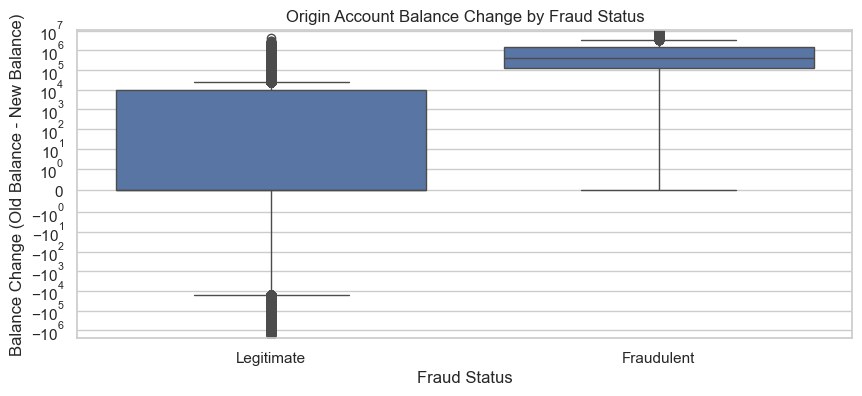

In [120]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x='isFraud',
    y='balance_change_orig'
)

plt.yscale('symlog', linthresh=1)

plt.title('Origin Account Balance Change by Fraud Status')
plt.xlabel('Fraud Status')
plt.ylabel('Balance Change (Old Balance - New Balance)')
plt.xticks([0, 1], ['Legitimate', 'Fraudulent'])

plt.show()

### 5.4.4 Destination Account Balance vs Fraud

### Key Finding

The destination account balance before the transaction shows some difference between legitimate and fraudulent transactions. The mean `oldbalanceDest` is approximately ₹11.01 lakh for legitimate transactions compared with ₹5.44 lakh for fraudulent transactions.

The median destination balance is ₹133,311.80 for legitimate transactions but ₹0 for fraudulent transactions. This indicates that fraudulent transactions are more frequently associated with destination accounts having zero or very low recorded balances before the transaction.

However, the large number of zero values in both groups reduces the ability of this feature to clearly distinguish fraudulent transactions on its own.

### Conclusion

`oldbalanceDest` provides some useful information for fraud analysis, but it appears to be a weaker standalone indicator than the origin-account balance change. It should therefore be considered together with other transaction and balance-related features.

In [121]:
df.groupby('isFraud')['oldbalanceDest'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.101421e+06,3.399202e+06,0.0,0.0,133311.8,944144.58,3.560159e+08
1,8213.0,5.442496e+05,3.336421e+06,0.0,0.0,0.0,147828.66,2.362305e+08


In [122]:
df.groupby('isFraud')['oldbalanceDest'].median()

isFraud
0    133311.8
1         0.0
Name: oldbalanceDest, dtype: float64

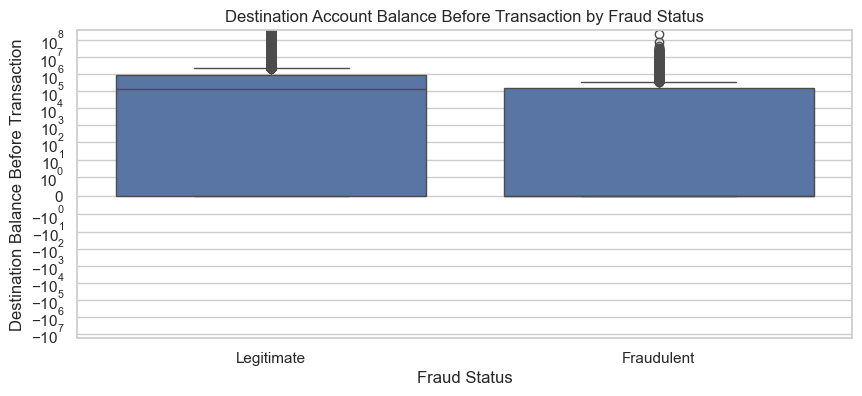

In [123]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x='isFraud',
    y='oldbalanceDest'
)

plt.yscale('symlog', linthresh=1)

plt.title('Destination Account Balance Before Transaction by Fraud Status')
plt.xlabel('Fraud Status')
plt.ylabel('Destination Balance Before Transaction')
plt.xticks([0, 1], ['Legitimate', 'Fraudulent'])

plt.show()

### 5.4.5 New Destination Account Balance vs Fraud
### Key Finding

The mean `newbalanceDest` is approximately ₹12.25 lakh for legitimate transactions and ₹12.80 lakh for fraudulent transactions, showing relatively similar average values.

However, the median values differ considerably. The median destination balance after the transaction is approximately ₹2.15 lakh for legitimate transactions compared with only ₹4,676 for fraudulent transactions.

This indicates that fraudulent transactions are more frequently associated with destination accounts having very low remaining balances after the transaction.

### Conclusion

`newbalanceDest` shows some relationship with fraud, particularly through its median and distribution. However, the similarity in mean values and the presence of extreme values suggest that this feature should not be used alone to identify fraudulent transactions.

In [124]:
df.groupby('isFraud')['newbalanceDest'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.224926e+06,3.673816e+06,0.0,0.0,214881.70,1111975.345,3.561793e+08
1,8213.0,1.279708e+06,3.908817e+06,0.0,0.0,4676.42,1058725.220,2.367265e+08


In [125]:
df.groupby('isFraud')['newbalanceDest'].median()

isFraud
0    214881.70
1      4676.42
Name: newbalanceDest, dtype: float64

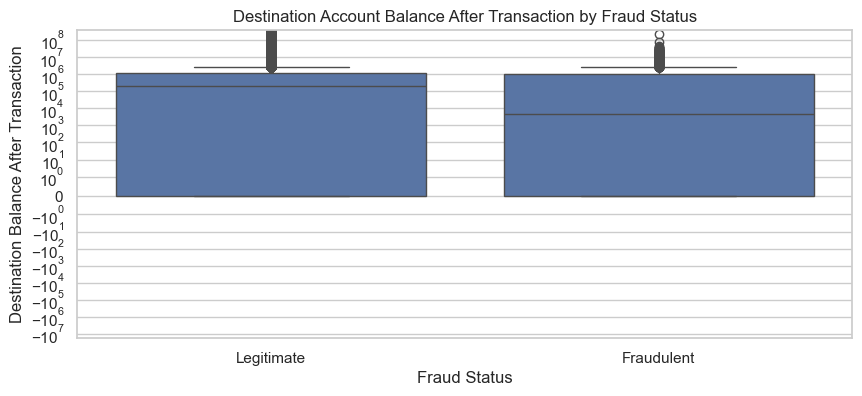

In [126]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x='isFraud',
    y='newbalanceDest'
)

plt.yscale('symlog', linthresh=1)

plt.title('Destination Account Balance After Transaction by Fraud Status')
plt.xlabel('Fraud Status')
plt.ylabel('Destination Balance After Transaction')
plt.xticks([0, 1], ['Legitimate', 'Fraudulent'])

plt.show()

### 5.4.6 Destination Account Balance Change vs Fraud
### Key Finding

The median destination account balance change is ₹0 for both legitimate and fraudulent transactions, indicating that a large proportion of transactions show no recorded change in the destination balance.

However, the upper distribution differs considerably. The 75th percentile of balance change is approximately ₹148,983 for legitimate transactions compared with ₹445,257 for fraudulent transactions.

The mean balance change is also substantially higher for fraudulent transactions (approximately ₹735,458) than for legitimate transactions (approximately ₹123,505).

This suggests that fraudulent transactions tend to be associated with larger increases in destination account balances, although the strong skewness and presence of extreme values indicate that the mean should be interpreted cautiously.

In [127]:
df['balance_change_dest'] = (
    df['newbalanceDest'] - df['oldbalanceDest']
)

df.groupby('isFraud')['balance_change_dest'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,123504.809994,8.104223e+05,-13060826.21,0.0,0.0,148982.64,1.056878e+08
1,8213.0,735457.998071,1.856984e+06,-315226.07,0.0,0.0,445257.43,1.491511e+07


In [128]:
df.groupby('isFraud')['balance_change_dest'].median()

isFraud
0    0.0
1    0.0
Name: balance_change_dest, dtype: float64

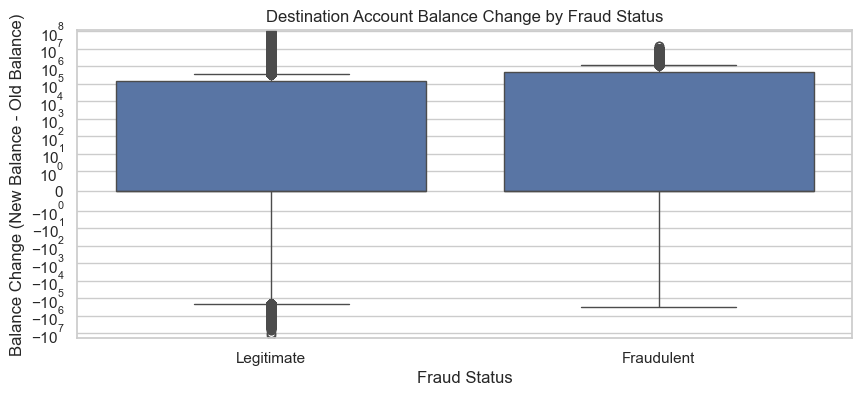

In [129]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x='isFraud',
    y='balance_change_dest'
)

plt.yscale('symlog', linthresh=1)

plt.title('Destination Account Balance Change by Fraud Status')
plt.xlabel('Fraud Status')
plt.ylabel('Balance Change (New Balance - Old Balance)')
plt.xticks([0, 1], ['Legitimate', 'Fraudulent'])

plt.show()

### 5.4.7 Overall Findings: Account Balance Changes vs Fraud

The analysis shows clear differences in account balance behavior between legitimate and fraudulent transactions.

- Fraudulent transactions generally start with higher origin account balances than legitimate transactions.
- The median origin account balance before fraudulent transactions is substantially higher.
- The median origin balance after the transaction is ₹0 for both groups, indicating that fraudulent transactions frequently drain the origin account.
- The origin account balance change is much larger for fraudulent transactions, with a median change of approximately ₹436,317 compared with ₹0 for legitimate transactions.
- Destination account balances show less separation when comparing mean values because of extreme values.
- However, the median destination balance after fraudulent transactions is considerably lower than for legitimate transactions.
- Destination balance changes have a higher mean and upper quartile for fraudulent transactions, indicating larger balance increases in fraudulent cases.
- The distributions are highly skewed, with substantial outliers, so median and percentile-based comparisons are more informative than means alone.

### Business Insight

Large changes in origin account balances, particularly substantial depletion of the source account, appear to be strong indicators of fraudulent activity. Destination-side balance changes also provide useful information, although their distributions are highly skewed.

These account balance features should therefore be considered important variables for subsequent fraud detection modeling.

## 5.5 Transaction Type vs Fraud
### Business Insight

- Fraud is concentrated in **TRANSFER** and **CASH_OUT** transactions.
- **TRANSFER** has the highest fraud rate at approximately **0.77%**, making it the riskiest transaction type.
- **CASH_OUT** has a fraud rate of approximately **0.18%**.
- No fraudulent transactions were observed in **CASH_IN, DEBIT, or PAYMENT** transactions.
- Although CASH_OUT has slightly more fraudulent transactions than TRANSFER, TRANSFER has a much higher fraud rate because it has fewer total transactions.
- Therefore, fraud detection systems should give higher priority to **TRANSFER and CASH_OUT** transactions.

In [130]:
type_fraud = df.groupby('type')['isFraud'].agg(['count', 'sum', 'mean'])

type_fraud['fraud_rate'] = type_fraud['mean'] * 100

type_fraud

,count,sum,mean,fraud_rate
type,,,,
CASH_IN,1399284,0,0.000000,0.000000
CASH_OUT,2237500,4116,0.001840,0.183955
DEBIT,41432,0,0.000000,0.000000
PAYMENT,2151495,0,0.000000,0.000000
TRANSFER,532909,4097,0.007688,0.768799


In [131]:
type_fraud.sort_values(
    'fraud_rate',
    ascending=False
)

,count,sum,mean,fraud_rate
type,,,,
TRANSFER,532909,4097,0.007688,0.768799
CASH_OUT,2237500,4116,0.001840,0.183955
CASH_IN,1399284,0,0.000000,0.000000
DEBIT,41432,0,0.000000,0.000000
PAYMENT,2151495,0,0.000000,0.000000


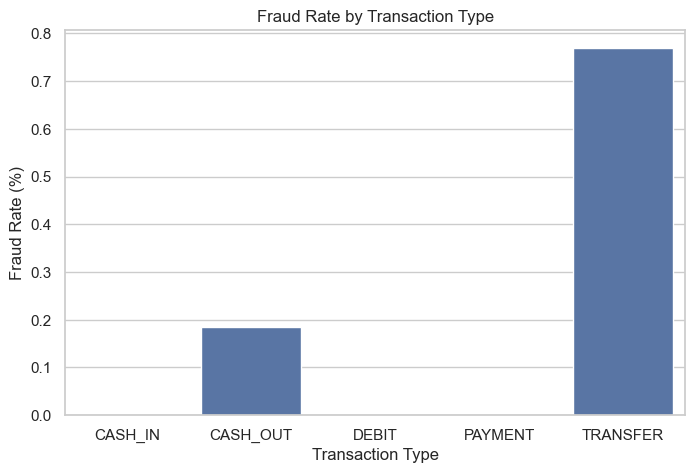

In [132]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=type_fraud.reset_index(),
    x='type',
    y='fraud_rate'
)

plt.title('Fraud Rate by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')

plt.show()

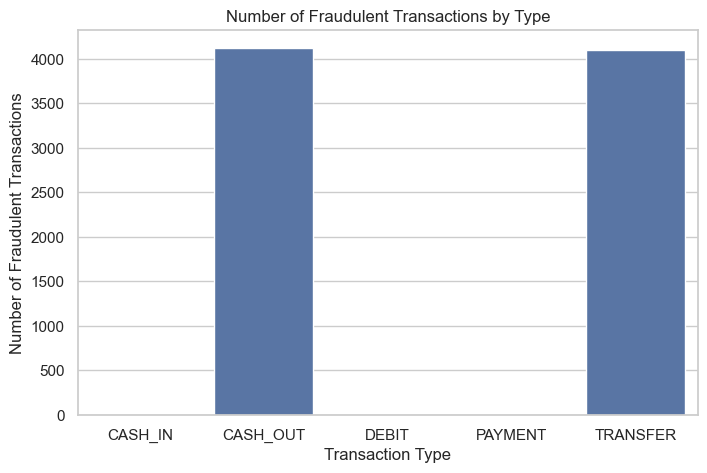

In [133]:
fraud_count_by_type = df.groupby('type')['isFraud'].sum()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=fraud_count_by_type.index,
    y=fraud_count_by_type.values
)

plt.title('Number of Fraudulent Transactions by Type')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Fraudulent Transactions')

plt.show()

## 5.6 Transaction Amount vs Fraud
### Business Insight

Transaction amount shows a strong relationship with fraud risk.

Fraudulent transactions have a substantially higher transaction amount than legitimate transactions. The median fraudulent transaction amount is approximately ₹4.41 lakh, compared with ₹74.68 thousand for legitimate transactions.

Fraud rate also increases consistently with transaction amount. Transactions above ₹1 million have the highest fraud rate at approximately 2.07%, compared with only 0.02% for transactions below ₹10,000.

The high-value transaction analysis further supports this pattern. The overall fraud rate is approximately 0.129%, while transactions in the top 10% by amount have a fraud rate of approximately 0.693%, which is more than five times higher.

Therefore, high-value transactions should be considered higher-risk and may require additional fraud monitoring. However, transaction amount alone should not be used to identify fraud because legitimate transactions can also involve very large amounts.

In [135]:
df.groupby('isFraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [136]:
df.groupby('isFraud')['amount'].median()

isFraud
0     74684.72
1    441423.44
Name: amount, dtype: float64

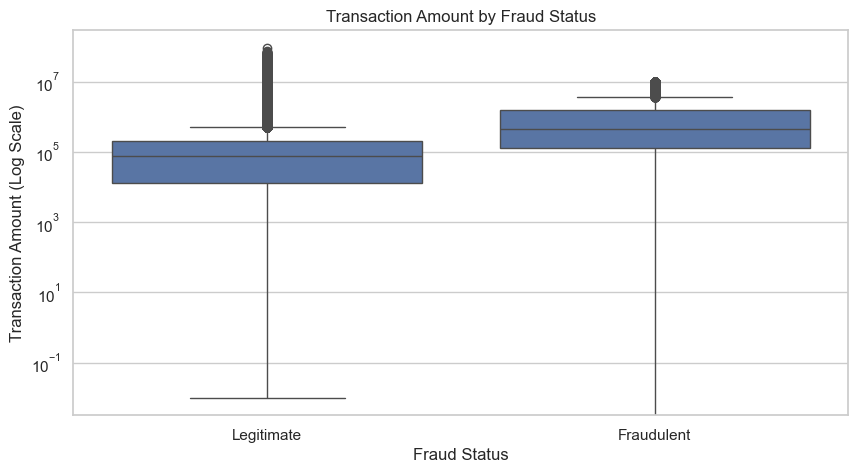

In [137]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x='isFraud',
    y='amount'
)

plt.yscale('log')

plt.title('Transaction Amount by Fraud Status')
plt.xlabel('Fraud Status')
plt.ylabel('Transaction Amount (Log Scale)')
plt.xticks([0, 1], ['Legitimate', 'Fraudulent'])

plt.show()

In [141]:
#5.6.1 Fraud Rate by Amount Range
amount_bins = [0, 10000, 50000, 100000, 500000, 1000000, float('inf')]

amount_labels = [
    '0-10K',
    '10K-50K',
    '50K-100K',
    '100K-500K',
    '500K-1M',
    '1M+'
]

df['amount_range'] = pd.cut(
    df['amount'],
    bins=amount_bins,
    labels=amount_labels,
    include_lowest=True
)

fraud_by_amount = df.groupby(
    'amount_range',
    observed=False
)['isFraud'].agg(['count', 'sum', 'mean'])

fraud_by_amount['fraud_rate'] = fraud_by_amount['mean'] * 100

fraud_by_amount

,count,sum,mean,fraud_rate
amount_range,,,,
0-10K,1286091,278,0.000216,0.021616
10K-50K,1519856,760,0.000500,0.050005
50K-100K,719351,669,0.000930,0.093000
100K-500K,2497038,2642,0.001058,0.105805
500K-1M,209658,1158,0.005523,0.552328
1M+,130626,2706,0.020716,2.071563


In [143]:
#5.6.2 Sort by Fraud Rate
fraud_by_amount.sort_values(
    'fraud_rate',
    ascending=False
)

,count,sum,mean,fraud_rate
amount_range,,,,
1M+,130626,2706,0.020716,2.071563
500K-1M,209658,1158,0.005523,0.552328
100K-500K,2497038,2642,0.001058,0.105805
50K-100K,719351,669,0.000930,0.093000
10K-50K,1519856,760,0.000500,0.050005
0-10K,1286091,278,0.000216,0.021616


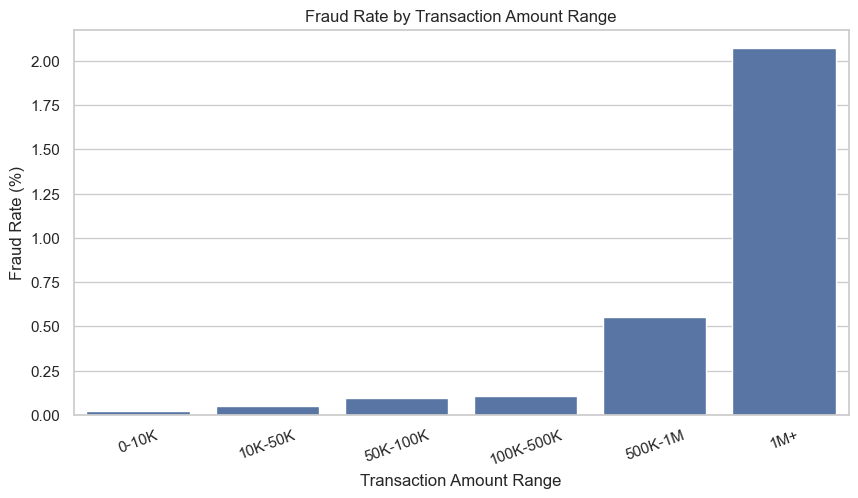

In [144]:
#5.6.3 Plot Fraud Rate by Amount Range
plt.figure(figsize=(10, 5))

sns.barplot(
    data=fraud_by_amount.reset_index(),
    x='amount_range',
    y='fraud_rate'
)

plt.title('Fraud Rate by Transaction Amount Range')
plt.xlabel('Transaction Amount Range')
plt.ylabel('Fraud Rate (%)')

plt.xticks(rotation=20)

plt.show()

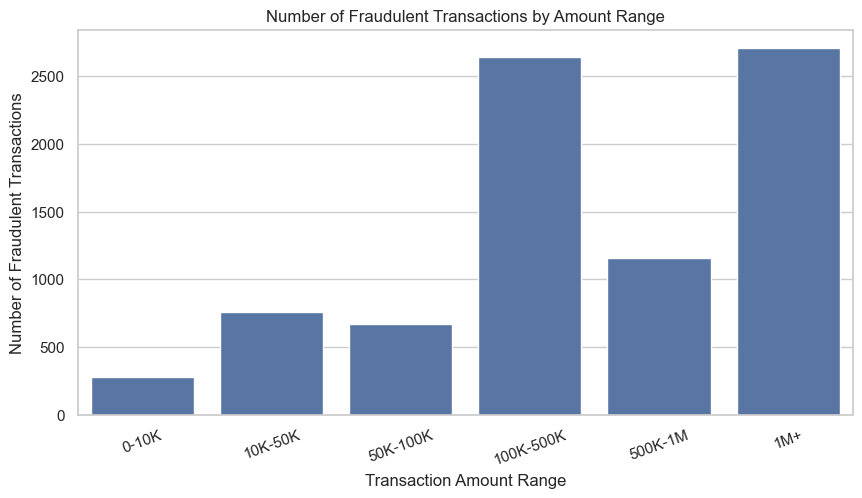

In [145]:
#5.6.4 Fraud Count by Amount Range
plt.figure(figsize=(10, 5))


sns.barplot(
    data=fraud_by_amount.reset_index(),
    x='amount_range',
    y='sum'
)


plt.title('Number of Fraudulent Transactions by Amount Range')
plt.xlabel('Transaction Amount Range')
plt.ylabel('Number of Fraudulent Transactions')


plt.xticks(rotation=20)


plt.show()

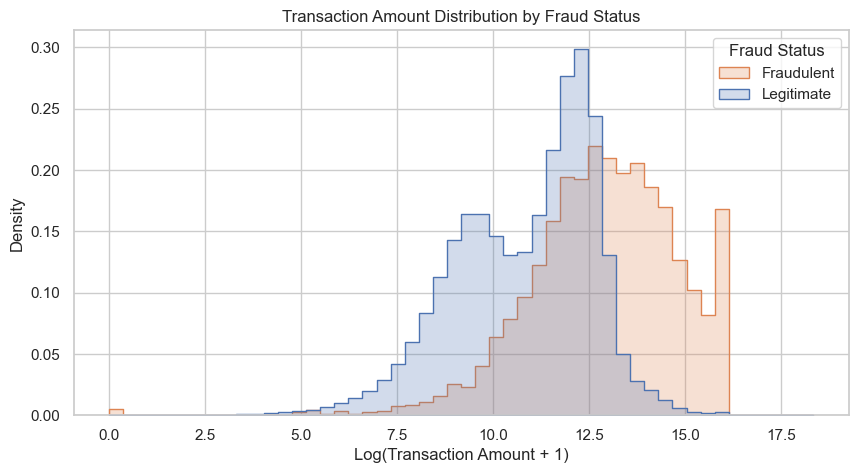

In [146]:
#5.6.5 Compare Amount Distribution Using Histograms
df['log_amount'] = np.log1p(df['amount'])

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='log_amount',
    hue='isFraud',
    bins=50,
    element='step',
    stat='density',
    common_norm=False
)

plt.title('Transaction Amount Distribution by Fraud Status')
plt.xlabel('Log(Transaction Amount + 1)')
plt.ylabel('Density')

plt.legend(
    title='Fraud Status',
    labels=['Fraudulent', 'Legitimate']
)

plt.show()

In [147]:
#5.6.6 Fraud Rate for High-Value Transactions
high_value_threshold = df['amount'].quantile(0.90)

high_value = df[df['amount'] >= high_value_threshold]

high_value_fraud_rate = high_value['isFraud'].mean() * 100

print(f"90th Percentile Amount: ₹{high_value_threshold:,.2f}")
print(f"High-Value Transaction Fraud Rate: {high_value_fraud_rate:.4f}%")

90th Percentile Amount: ₹365,423.31
High-Value Transaction Fraud Rate: 0.6934%


In [148]:
#5.6.7 Compare Overall vs High-Value Fraud Rate
overall_fraud_rate = df['isFraud'].mean() * 100

comparison = pd.DataFrame({
    'Group': ['All Transactions', 'Top 10% High-Value Transactions'],
    'Fraud Rate (%)': [
        overall_fraud_rate,
        high_value_fraud_rate
    ]
})

comparison

,Group,Fraud Rate (%)
0,All Transactions,0.129082
1,Top 10% High-Value Transactions,0.693425


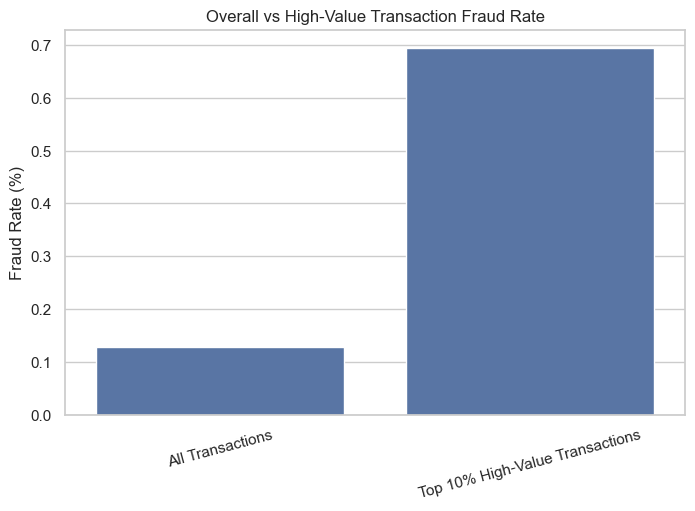

In [149]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x='Group',
    y='Fraud Rate (%)'
)

plt.title('Overall vs High-Value Transaction Fraud Rate')
plt.xlabel('')
plt.ylabel('Fraud Rate (%)')

plt.xticks(rotation=15)

plt.show()

## 5.7 Transaction Amount vs Transaction Type
### Business Insight

Transaction amount varies substantially across transaction types, and this variation is closely related to fraud risk.

TRANSFER transactions have the highest median transaction amount at approximately ₹4.86 lakh and also show the highest fraud rate of 0.77%. CASH_OUT transactions have the second-highest median amount at approximately ₹1.47 lakh and a fraud rate of 0.18%.

In contrast, PAYMENT and DEBIT transactions have much lower median transaction amounts and show no fraudulent transactions in this dataset. CASH_IN transactions have a relatively high median amount but also show a 0% fraud rate.

These findings indicate that transaction amount alone is not sufficient to identify fraud. The transaction type provides important additional context. In particular, high-value TRANSFER and CASH_OUT transactions appear to represent higher-risk transaction patterns and should receive greater attention in fraud monitoring.

Therefore, combining transaction amount with transaction type can provide a more useful signal for identifying potentially fraudulent transactions.

In [150]:
#5.7.1 Amount Statistics by Transaction Type
amount_by_type = (
    df.groupby('type')['amount']
      .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
)

amount_by_type

,count,mean,median,std,min,max
type,,,,,,
CASH_IN,1399284,168920.242004,143427.710,1.265083e+05,0.04,1915267.90
CASH_OUT,2237500,176273.964346,147072.185,1.753297e+05,0.00,10000000.00
DEBIT,41432,5483.665314,3048.990,1.331854e+04,0.55,569077.51
PAYMENT,2151495,13057.604660,9482.190,1.255645e+04,0.02,238637.98
TRANSFER,532909,910647.009645,486308.390,1.879574e+06,2.60,92445516.64


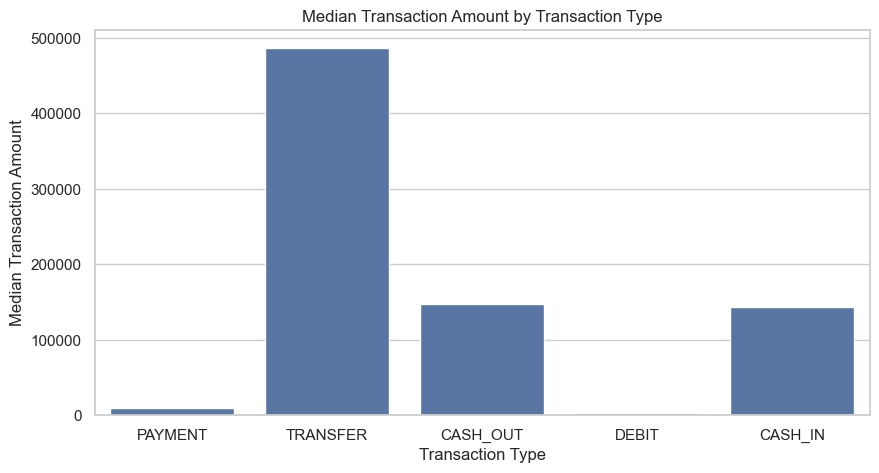

In [151]:
#5.7.2 Median Transaction Amount by Type
plt.figure(figsize=(10, 5))


sns.barplot(
    data=df,
    x='type',
    y='amount',
    estimator='median',
    errorbar=None
)


plt.title('Median Transaction Amount by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Median Transaction Amount')


plt.show()

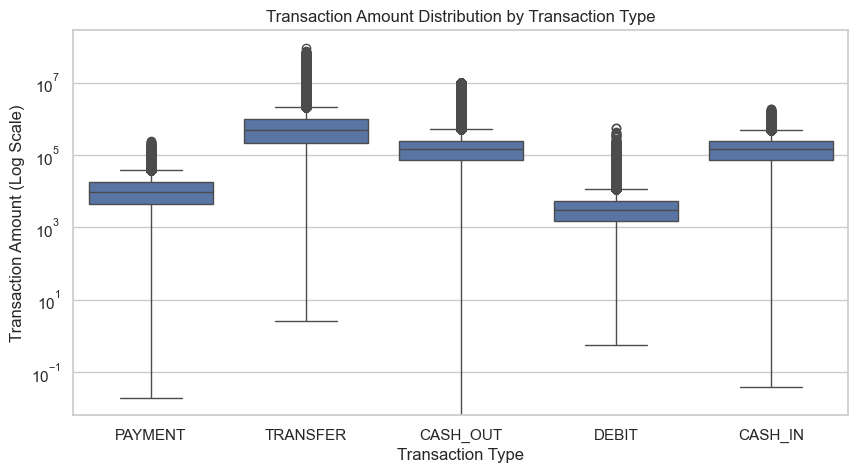

In [152]:
#5.7.3 Transaction Amount Distribution by Type
plt.figure(figsize=(10, 5))


sns.boxplot(
    data=df,
    x='type',
    y='amount'
)


plt.yscale('log')


plt.title('Transaction Amount Distribution by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Transaction Amount (Log Scale)')


plt.show()

In [153]:
#5.7.4 Fraud Rate + Amount Together
type_summary = (
    df.groupby('type')
      .agg(
          transaction_count=('isFraud', 'count'),
          fraud_count=('isFraud', 'sum'),
          median_amount=('amount', 'median')
      )
)


type_summary['fraud_rate'] = (
    type_summary['fraud_count'] /
    type_summary['transaction_count']
) * 100


type_summary.sort_values(
    'fraud_rate',
    ascending=False
)

,transaction_count,fraud_count,median_amount,fraud_rate
type,,,,
TRANSFER,532909,4097,486308.390,0.768799
CASH_OUT,2237500,4116,147072.185,0.183955
CASH_IN,1399284,0,143427.710,0.000000
DEBIT,41432,0,3048.990,0.000000
PAYMENT,2151495,0,9482.190,0.000000


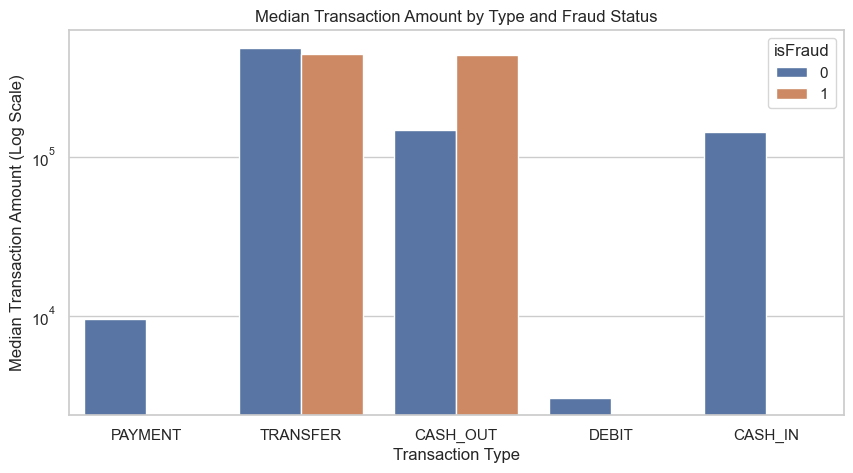

In [154]:
#5.7.5 Transaction Type × Fraud
plt.figure(figsize=(10, 5))


sns.barplot(
    data=df,
    x='type',
    y='amount',
    hue='isFraud',
    estimator='median',
    errorbar=None
)


plt.yscale('log')


plt.title('Median Transaction Amount by Type and Fraud Status')
plt.xlabel('Transaction Type')
plt.ylabel('Median Transaction Amount (Log Scale)')


plt.show()

## 5.8 Time-Based Fraud Analysis
### Key Insights

- Fraudulent transactions are distributed across the entire observation period, but their frequency varies considerably over time.
- Transaction volume is substantially higher during the earlier time steps and decreases considerably in the later period.
- Several individual time steps show a 100% fraud rate; however, these periods contain very few transactions and therefore should not be treated as reliable indicators of high-risk periods.
- Aggregating transactions into broader time windows provides a more stable view of temporal fraud patterns.
- Time-based patterns may therefore be useful as features in a fraud detection model, especially when combined with transaction type, amount, and account-related features.

In [155]:
# 5.8.1 Fraud Rate by Time Step

fraud_by_step = (
    df.groupby('step')['isFraud']
      .agg(['count', 'sum', 'mean'])
)

fraud_by_step['fraud_rate'] = fraud_by_step['mean'] * 100

fraud_by_step.head()

,count,sum,mean,fraud_rate
step,,,,
1,2708,16,0.005908,0.590842
2,1014,8,0.007890,0.788955
3,552,4,0.007246,0.724638
4,565,10,0.017699,1.769912
5,665,6,0.009023,0.902256


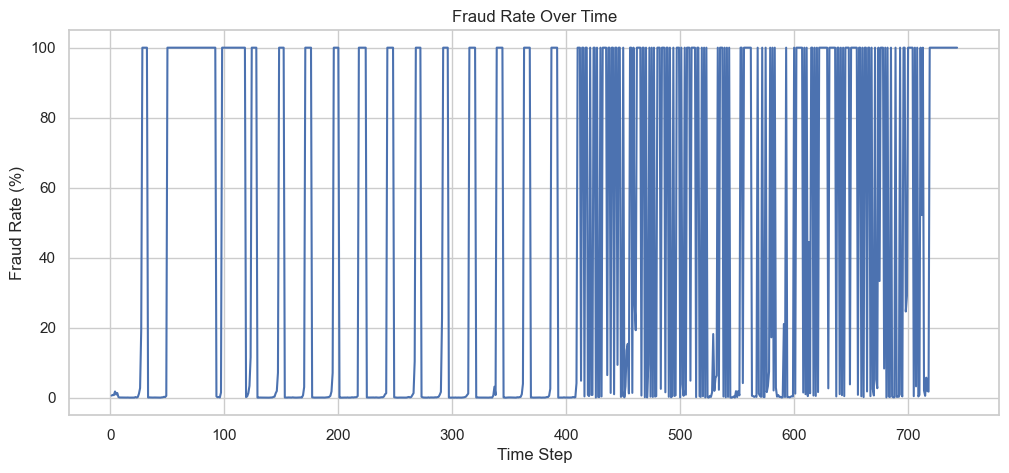

In [157]:
# 5.8.2 Plot Fraud Rate Over Time

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=fraud_by_step,
    x=fraud_by_step.index,
    y='fraud_rate'
)

plt.title('Fraud Rate Over Time')
plt.xlabel('Time Step')
plt.ylabel('Fraud Rate (%)')

plt.show()

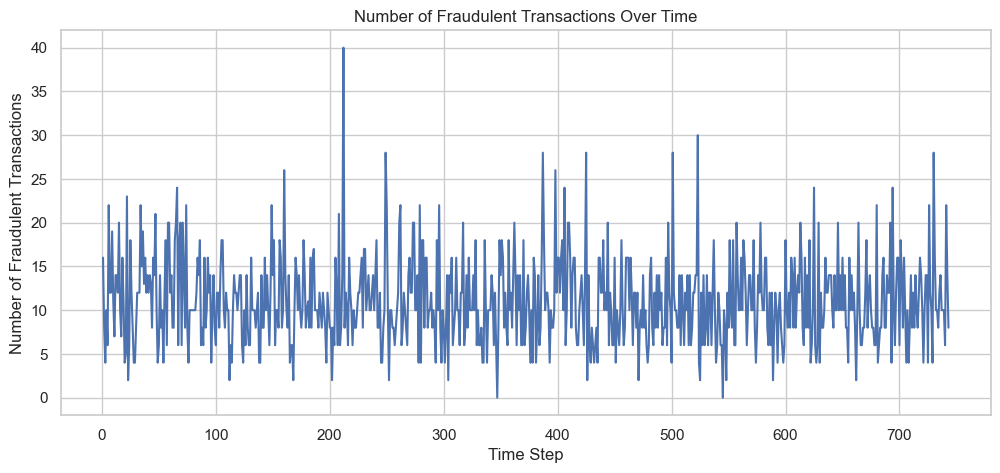

In [158]:
# 5.8.3 Fraud Count Over Time

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=fraud_by_step,
    x=fraud_by_step.index,
    y='sum'
)

plt.title('Number of Fraudulent Transactions Over Time')
plt.xlabel('Time Step')
plt.ylabel('Number of Fraudulent Transactions')

plt.show()

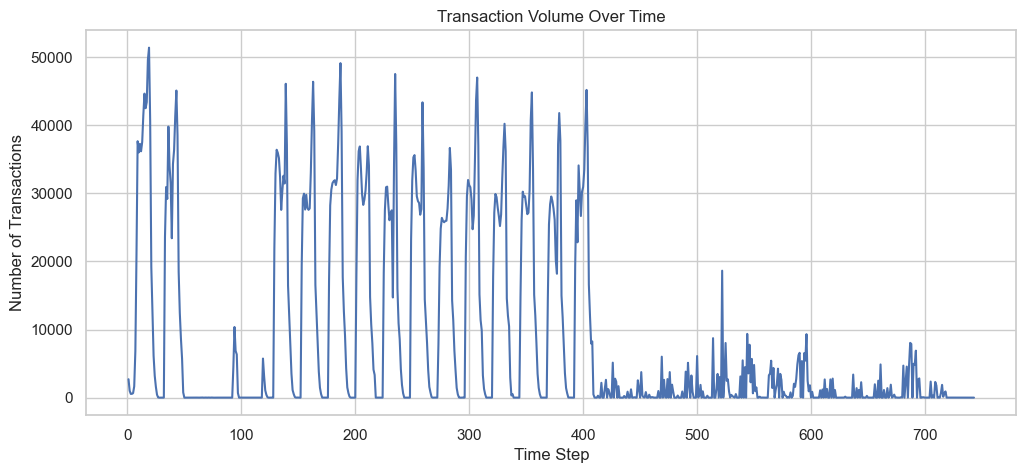

In [159]:
# 5.8.4 Transaction Volume Over Time

transaction_volume = df.groupby('step').size()

plt.figure(figsize=(12, 5))

sns.lineplot(
    x=transaction_volume.index,
    y=transaction_volume.values
)

plt.title('Transaction Volume Over Time')
plt.xlabel('Time Step')
plt.ylabel('Number of Transactions')

plt.show()

In [160]:
# 5.8.5 Highest Fraud-Rate Time Periods

fraud_by_step.sort_values(
    'fraud_rate',
    ascending=False
).head(10)

,count,sum,mean,fraud_rate
step,,,,
743,8,8,1.0,100.0
533,12,12,1.0,100.0
269,14,14,1.0,100.0
268,6,6,1.0,100.0
568,14,14,1.0,100.0
572,18,18,1.0,100.0
575,8,8,1.0,100.0
579,12,12,1.0,100.0
581,10,10,1.0,100.0


In [161]:
# 5.8.6 Fraud Rate by Time Window

df['time_window'] = pd.cut(
    df['step'],
    bins=20
)

fraud_by_window = (
    df.groupby('time_window', observed=True)['isFraud']
      .agg(['count', 'sum', 'mean'])
)

fraud_by_window['fraud_rate'] = fraud_by_window['mean'] * 100

fraud_by_window

,count,sum,mean,fraud_rate
time_window,,,,
"(0.258, 38.1]",765278,446,0.000583,0.058279
"(38.1, 75.2]",265323,482,0.001817,0.181665
"(75.2, 112.3]",29049,396,0.013632,1.363214
"(112.3, 149.4]",451704,372,0.000824,0.082355
"(149.4, 186.5]",736533,426,0.000578,0.057839
"(186.5, 223.6]",553250,385,0.000696,0.069589
"(223.6, 260.7]",769795,418,0.000543,0.054300
"(260.7, 297.8]",410023,454,0.001107,0.110725
"(297.8, 334.9]",790432,366,0.000463,0.046304


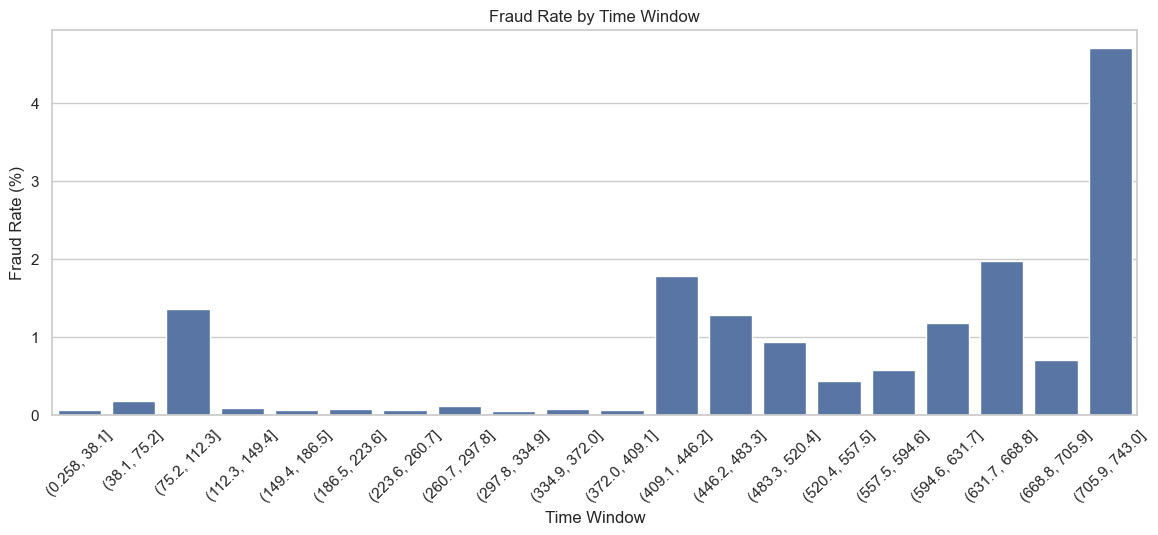

In [162]:
# Fraud Rate by Time Window

plt.figure(figsize=(14, 5))

sns.barplot(
    data=fraud_by_window.reset_index(),
    x='time_window',
    y='fraud_rate',
    errorbar=None
)

plt.title('Fraud Rate by Time Window')
plt.xlabel('Time Window')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)

plt.show()

In [163]:
# 5.8.7 Highest Fraud Volume Time Windows

fraud_by_window.sort_values(
    'sum',
    ascending=False
).head(10)

,count,sum,mean,fraud_rate
time_window,,,,
"(38.1, 75.2]",265323,482,0.001817,0.181665
"(372.0, 409.1]",702012,456,0.000650,0.064956
"(260.7, 297.8]",410023,454,0.001107,0.110725
"(0.258, 38.1]",765278,446,0.000583,0.058279
"(149.4, 186.5]",736533,426,0.000578,0.057839
"(705.9, 743.0]",9003,424,0.047095,4.709541
"(668.8, 705.9]",59845,422,0.007052,0.705155
"(223.6, 260.7]",769795,418,0.000543,0.054300
"(409.1, 446.2]",23049,410,0.017788,1.778819
